# RetailHero Purchase Uplift Modeling Experiment

## Problem Definition

The RetailHero dataset was released by X5 Retail Group for an uplift-modeling competition on promotional communication.

The business setting is customer targeting for an advertising SMS campaign.

A conventional response model asks:

> Which customers are most likely to make a purchase?

For campaign targeting, however, the more relevant question is:

> Which customers are more likely to make a purchase **because they receive the promotional communication**?

A customer who is already very likely to purchase may receive a high response score even if the campaign does not change their behavior. Uplift modeling instead focuses on the **incremental effect of treatment**.

The objective of this experiment is therefore to compare conventional response-based targeting with uplift-based targeting.

The main decision question is:

> **Under a limited targeting budget, which policy selects customers with the highest incremental purchase outcome?**

The experiment compares:

* **Response Model** as the conventional targeting baseline;
* **T-Learner** as an uplift-model candidate;
* **X-Learner** as an uplift-model candidate.

The goal is not exhaustive hyperparameter optimization. The goal is to compare these modeling approaches under the same prepared data structure, split strategy, validation protocol, and targeting budgets.


## EDA Direction

The EDA focuses on the **200,039 customers in `uplift_train`**.

The main goal is to understand what these customers looked like before the
campaign, then see whether those differences are connected to different
purchase outcomes after treatment.

The analysis follows a simple path:

1. Understand the customers and their purchase history.
2. Understand how common the positive outcome is.
3. Compare the overall purchase rate between Treatment and Control.
4. Check whether that difference becomes larger or smaller for different
   types of customers.

The patterns found here will be carried forward into hypothesis checks and
later feature engineering.

### Analysis Window

The purchase table is used as the available customer history before the
campaign.

For the experiment customers, the latest purchase timestamp is
**2019-03-18 23:19:28**. This is used as the end of the observed purchase
history when calculating measures such as recency.

It should not be read as the exact time when the campaign was sent.

Customer date fields such as `first_redeem_date` are not used in the main
pre-campaign analysis here because some values extend beyond the purchase
history window. They should only be turned into model features after their
timing relative to treatment is confirmed.

In [831]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

COLORS = {
    "pacific_green": "#017360",
    "rainy_lake": "#446E8F",
    "serene_sea": "#77A7C4",
    "sora_blue": "#A1DBF1",
    "afterglow": "#F2E6CE",
    "bungalow_maple": "#F3D094",
}

PALETTE = list(COLORS.values())

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize":11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [832]:
CLEAN_DIR = Path(
    r"d:\thao\d\uplif_model\uplif_customer_selection\data\interim\retailhero\clean"
)

DATA_PATHS = {
    "clients": CLEAN_DIR / "clients_clean.parquet",
    "products": CLEAN_DIR / "products_clean.parquet",
    "purchases": CLEAN_DIR / "purchases_clean.parquet",
    "uplift_train": CLEAN_DIR / "uplift_train_clean.parquet",
}

con = duckdb.connect()

for name, path in DATA_PATHS.items():
    con.execute(
        f"""
        CREATE OR REPLACE VIEW {name} AS
        SELECT *
        FROM read_parquet('{path.as_posix()}')
        """
    )

In [833]:
dataset_overview = []

for name in DATA_PATHS:
    row_count = con.sql(
        f"SELECT COUNT(*) AS n FROM {name}"
    ).fetchone()[0]

    column_count = len(
        con.sql(f"DESCRIBE {name}").df()
    )

    dataset_overview.append({
        "dataset": name,
        "rows": row_count,
        "columns": column_count,
    })

dataset_overview = pd.DataFrame(dataset_overview)

display(dataset_overview)

,dataset,rows,columns
0,clients,400162,5
1,products,43038,11
2,purchases,45786568,13
3,uplift_train,200039,3


The EDA population is the **200,039 customers in `uplift_train`**.  
The other tables are used to add customer profile, purchase history, and product information for these customers.

## Experiment Structure Check

Before looking for customer patterns, first make sure the labeled experiment
has a usable structure.

This check covers:

- One row per customer;
- Valid treatment and outcome values;
- Treatment and Control group sizes;
- Basic age and gender balance between the two groups.

The purpose is only to make sure there are no obvious structural problems
before the EDA. It does not prove that treatment assignment was randomized.

In [834]:
experiment_check = con.sql(
    """
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT client_id) AS unique_clients,

        SUM(CASE WHEN treatment_flg = 0 THEN 1 ELSE 0 END) AS control,
        SUM(CASE WHEN treatment_flg = 1 THEN 1 ELSE 0 END) AS treatment,

        SUM(CASE WHEN treatment_flg NOT IN (0, 1) OR treatment_flg IS NULL
                 THEN 1 ELSE 0 END) AS invalid_treatment,

        SUM(CASE WHEN target NOT IN (0, 1) OR target IS NULL
                 THEN 1 ELSE 0 END) AS invalid_target
    FROM uplift_train
    """
).df()

display(experiment_check)

,rows,unique_clients,control,treatment,invalid_treatment,invalid_target
0,200039,200039,"100,058.0000","99,981.0000",0.0000,0.0000


In [835]:
treatment_distribution = con.sql(
    """
    SELECT
        treatment_flg,
        COUNT(*) AS customers,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
    FROM uplift_train
    GROUP BY treatment_flg
    ORDER BY treatment_flg
    """
).df()

display(treatment_distribution)

,treatment_flg,customers,percentage
0,0,100058,50.0192
1,1,99981,49.9808


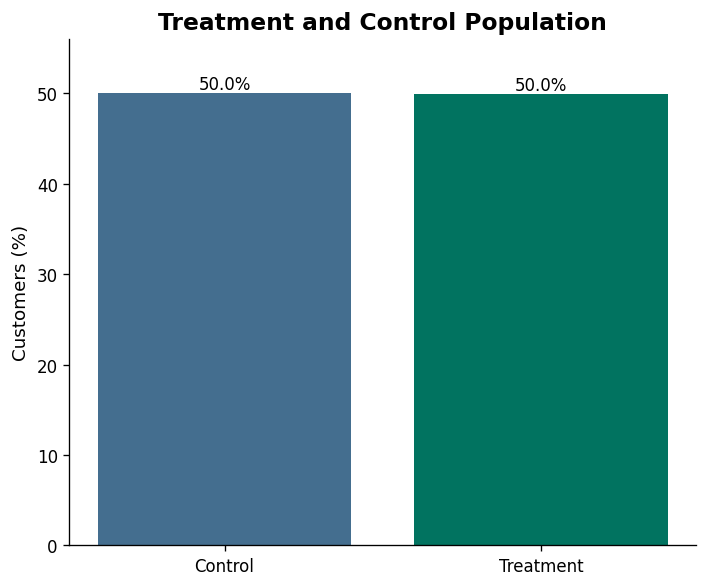

In [836]:
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    ["Control", "Treatment"],
    treatment_distribution["percentage"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

ax.set_title("Treatment and Control Population")
ax.set_ylabel("Customers (%)")

for bar, value in zip(
    bars,
    treatment_distribution["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_ylim(
    0,
    treatment_distribution["percentage"].max() * 1.12,
)

plt.tight_layout()
plt.show()

In [837]:
experiment_clients = con.sql(
    """
    SELECT
        u.client_id,
        u.treatment_flg,
        u.target,
        c.age,
        c.gender,
        c.first_issue_date,
        c.first_redeem_date
    FROM uplift_train AS u
    LEFT JOIN clients AS c
        USING (client_id)
    """
).df()

In [838]:
age_balance = (
    experiment_clients
    .groupby("treatment_flg")["age"]
    .agg(["count", "mean", "median"])
)

age_balance.index = ["Control", "Treatment"]

display(age_balance)

,count,mean,median
Control,99663,46.3657,45.0000
Treatment,99569,46.4514,45.0000


In [839]:
gender_balance = pd.crosstab(
    experiment_clients["gender"],
    experiment_clients["treatment_flg"],
    normalize="columns",
).mul(100)

gender_balance.columns = ["Control (%)", "Treatment (%)"]

display(gender_balance)

,Control (%),Treatment (%)
gender,,
F,36.7637,36.9180
M,16.7763,16.7282
U,46.4601,46.3538


#### Experiment Structure Findings

The experiment contains **200,039 unique customers**. Treatment and Control
are almost perfectly balanced in size, with **100,058 Control customers** and
**99,981 Treatment customers**.

Age and gender also look very similar between the two groups.

There is no obvious structural imbalance that would block the next EDA steps.

## 1. Customer and Pre-Campaign Purchase Behavior

Before looking at campaign outcomes, first understand what the customers
already looked like.

The analysis covers four simple parts of their previous shopping behavior:

- how recently and how often they purchased;
- how much they spent;
- how broadly they shopped across products;
- how they used different stores.

These behaviors give us different ways to describe a customer before
treatment. Later, we can check whether the Treatment-Control difference
changes along the same dimensions.

### 1.1 Customer Population

Age and gender do not tell us whether a customer will react to the campaign,
but they help us understand who is actually represented in the experiment
before moving to shopping behavior.

In [840]:
customer_population = con.sql(
    """
    SELECT
        u.client_id,
        c.*
        EXCLUDE (client_id)
    FROM uplift_train AS u
    LEFT JOIN clients AS c
        USING (client_id)
    """
).df()

print(f"EDA population: {len(customer_population):,}")
display(customer_population.head())

EDA population: 200,039


,client_id,first_issue_date,first_redeem_date,age,gender
0,ee43c35beb,2017-06-10 11:58:43,2017-12-28 16:25:54,63,M
1,ee43cc9492,2017-08-03 18:54:30,2017-10-13 11:06:27,49,F
2,ee443a393d,2017-07-11 18:20:38,2018-07-15 18:26:28,35,M
3,ee44445b00,2018-03-27 14:34:57,2019-07-15 11:54:13,37,F
4,ee44dc3920,2019-02-28 20:29:14,2019-07-26 21:00:19,36,U


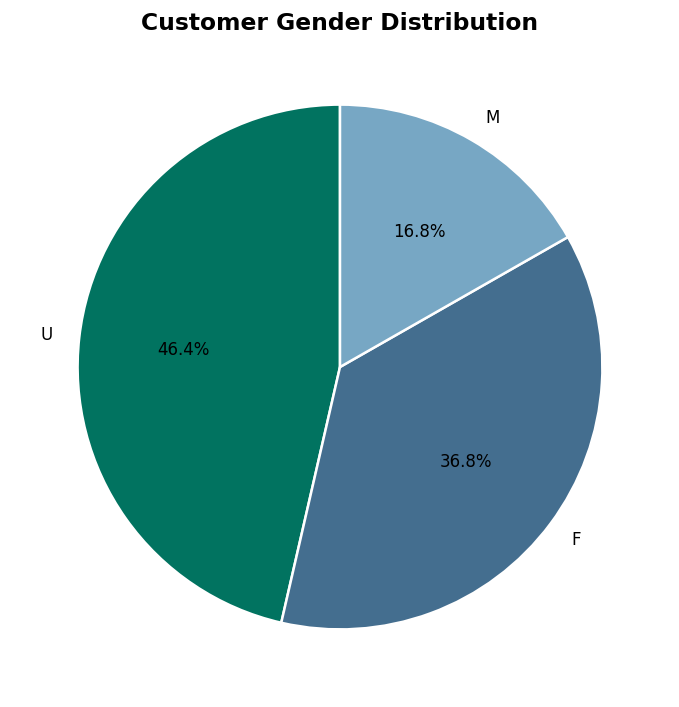

In [841]:
gender_counts = (
    customer_population["gender"]
    .fillna("Unknown")
    .value_counts()
)

gender_pct = gender_counts / gender_counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=PALETTE[:len(gender_counts)],
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.5,
    },
)

ax.set_title("Customer Gender Distribution")

plt.tight_layout()
plt.show()


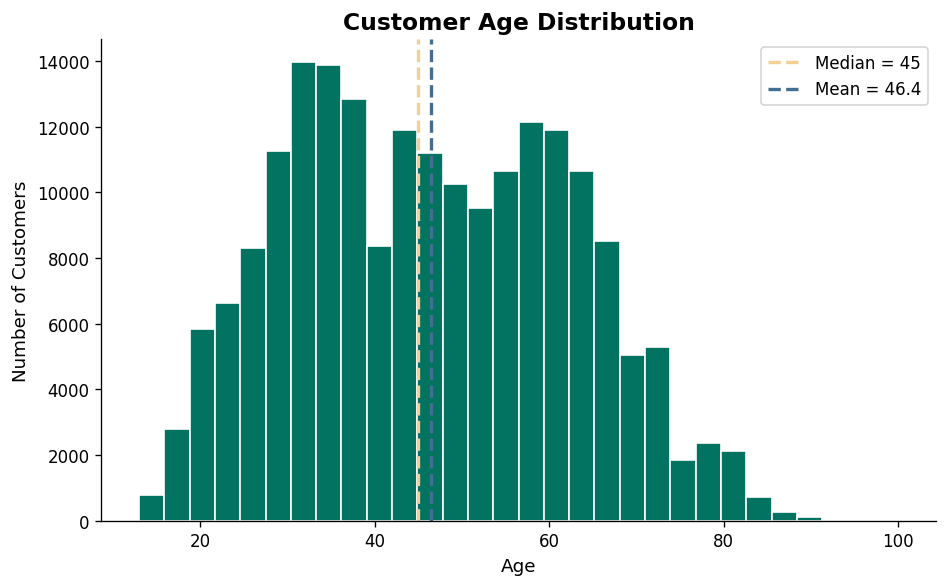

,count,mean,std,min,25%,50%,75%,max
age,"199,232.0000",46.4085,15.8856,13.0000,34.0000,45.0000,59.0000,100.0000


In [842]:
age = customer_population["age"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    age,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    age.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {age.median():.0f}",
)

ax.axvline(
    age.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {age.mean():.1f}",
)

ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

display(
    customer_population["age"]
    .describe()
    .to_frame("age")
    .T
)

#### Customer Population Findings

Gender is not evenly recorded across customers. The largest group is `U`
at **46.4%**, followed by `F` at **36.8%** and `M` at **16.8%**.

The important point here is that almost half of the customers fall into `U`.
So gender may still be useful, but for a large part of the population it does
not give us a very specific customer description.

Age contains more variation. The median customer is **45 years old**, and the
middle half of the population is between **34 and 59**. This gives us a fairly
broad age range rather than a customer base concentrated around one age group.

Age and gender give us some basic customer context, but they say little about
how strongly someone interacts with the retailer.


### 1.2 Historical Purchase Behavior

Customer profile tells us who is in the experiment. Purchase history tells us
how those customers were actually behaving before treatment.


#### Purchase Timeline

First, check how much pre-campaign purchase history is available for the experiment customers.

In [843]:
purchase_timeline = con.sql(
    """
    WITH experiment_purchases AS (
        SELECT p.*
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
    ),

    transactions AS (
        SELECT DISTINCT
            client_id,
            transaction_id,
            transaction_datetime,
            store_id
        FROM experiment_purchases
    )

    SELECT
        (SELECT MIN(transaction_datetime) FROM experiment_purchases)
            AS first_transaction,
        (SELECT MAX(transaction_datetime) FROM experiment_purchases)
            AS last_transaction,
        (SELECT COUNT(*) FROM experiment_purchases)
            AS purchase_rows,
        (SELECT COUNT(*) FROM transactions)
            AS transactions,
        (SELECT COUNT(DISTINCT client_id) FROM experiment_purchases)
            AS active_customers
    """
).df()

display(purchase_timeline)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_transaction,last_transaction,purchase_rows,transactions,active_customers
0,2018-11-21 21:02:33,2019-03-18 23:19:28,22882690,4024949,200039


#### Purchase Timeline

The available purchase history runs from **November 2018 to March 2019**, so
we have roughly four months of shopping activity before the outcome period.

All **200,039 experiment customers** appear in this purchase history.

This is important because the customer-behavior measures used later are not
being built from completely different history lengths across customers. We
have a common observation window that can be used to describe recent shopping
activity.

The end of this history is then used to measure how recently each customer
made their last purchase.

#### Recency

Recency measures how many days had passed since a customer's last purchase at
the end of the available purchase history.

A small value means the customer purchased very recently. A larger value
means they had been inactive for longer.

In [844]:
purchase_history_end = con.sql(
    """
    SELECT MAX(p.transaction_datetime)
    FROM purchases AS p
    INNER JOIN uplift_train AS u
        USING (client_id)
    """
).fetchone()[0]

print("Purchase history reference date:", purchase_history_end)

Purchase history reference date: 2019-03-18 23:19:28


In [845]:
customer_recency = con.sql(
    f"""
    WITH last_purchase AS (
        SELECT
            p.client_id,
            MAX(p.transaction_datetime) AS last_purchase_date
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
        GROUP BY p.client_id
    )

    SELECT
        u.client_id,
        lp.last_purchase_date,
        DATE_DIFF(
            'day',
            lp.last_purchase_date,
            TIMESTAMP '{purchase_history_end}'
        ) AS recency_days
    FROM uplift_train AS u
    LEFT JOIN last_purchase AS lp
        USING (client_id)
    """
).df()

display(customer_recency.head())

,client_id,last_purchase_date,recency_days
0,09178afc43,2019-02-28 06:40:17,18
1,0919b4eefa,2019-02-26 16:36:38,20
2,091a1c1eca,2019-03-18 13:28:44,0
3,091cf6cdc9,2019-03-16 16:55:31,2
4,091e1e8876,2019-03-17 13:36:57,1


In [846]:
display(
    customer_recency["recency_days"]
    .describe()
    .to_frame("recency_days")
    .T
)

,count,mean,std,min,25%,50%,75%,max
recency_days,"200,039.0000",5.8289,5.6680,0.0000,1.0000,4.0000,9.0000,22.0000


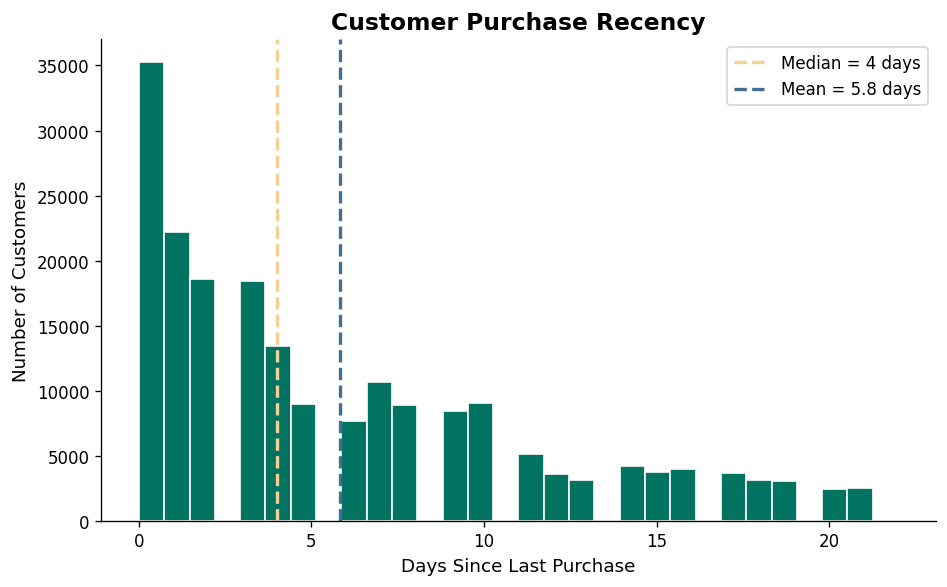

In [847]:
recency = customer_recency["recency_days"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    recency,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    recency.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {recency.median():.0f} days",
)

ax.axvline(
    recency.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {recency.mean():.1f} days",
)

ax.set_title("Customer Purchase Recency")
ax.set_xlabel("Days Since Last Purchase")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

#### Recency Findings

Customers in this dataset are generally recent shoppers.

The median recency is only **4 days**, and 75% of customers purchased within
the last **9 days**. At the same time, recency ranges from **0 to 22 days**.

So most customers were active fairly recently, but they were not all equally
recent. Some had purchased almost immediately before the end of the history,
while others had been inactive for several weeks.

That difference gives us a useful first measure of customer activity:
**how recently the customer was still shopping with the retailer**.



#### Frequency

Frequency measures the number of purchase transactions each customer made during the available pre-campaign history.

In [848]:
customer_frequency = con.sql(
    """
    WITH transactions AS (
        SELECT DISTINCT
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
    ),

    purchase_frequency AS (
        SELECT
            client_id,
            COUNT(*) AS transaction_count,
            COUNT(DISTINCT CAST(transaction_datetime AS DATE)) AS active_days
        FROM transactions
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        COALESCE(pf.transaction_count, 0) AS transaction_count,
        COALESCE(pf.active_days, 0) AS active_days
    FROM uplift_train AS u
    LEFT JOIN purchase_frequency AS pf
        USING (client_id)
    """
).df()

display(customer_frequency.head())

,client_id,transaction_count,active_days
0,08c985480d,30,27
1,145c56c94f,31,26
2,1470248fd8,5,5
3,1478974dc2,70,33
4,1c3bc9261b,26,24


In [849]:
display(
    customer_frequency[
        ["transaction_count", "active_days"]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
transaction_count,"200,039.0000",20.1208,17.7321,1.0000,8.0000,15.0000,27.0000,320.0000
active_days,"200,039.0000",17.8742,14.2211,1.0000,8.0000,14.0000,24.0000,115.0000


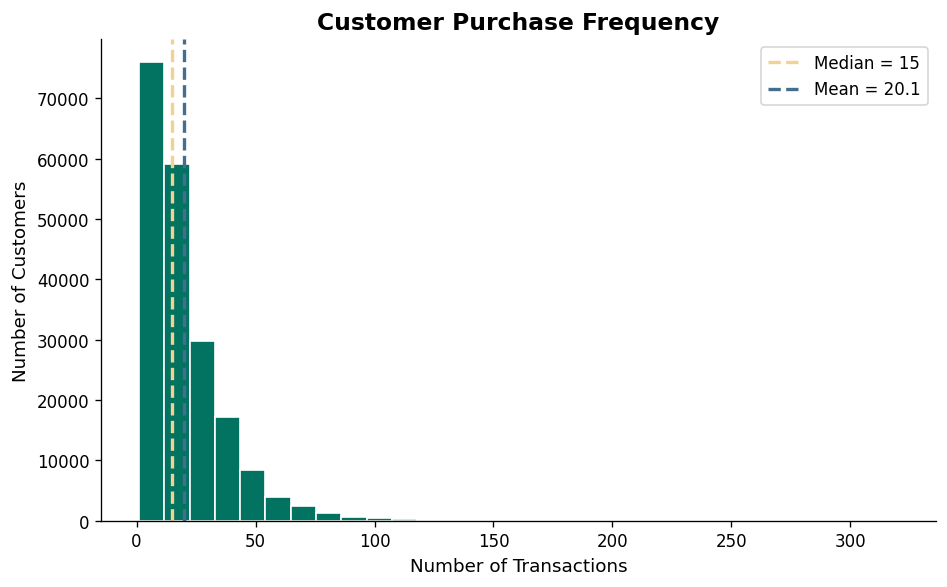

In [850]:
frequency = customer_frequency["transaction_count"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    frequency,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    frequency.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {frequency.median():.0f}",
)

ax.axvline(
    frequency.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {frequency.mean():.1f}",
)

ax.set_title("Customer Purchase Frequency")
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

#### Frequency Findings

The median customer made **15 transactions**, while the middle half of the
population made between **8 and 27**.

The mean is higher at **20.1 transactions**, and the maximum reaches **320**.
This tells us that most customers shop much less often than the small group of
very frequent shoppers at the far end of the distribution.

Customers were active on a median of **14 different purchase days**. That is
very close to the median of 15 transactions.

So for a typical customer, a higher transaction count mostly represents
shopping on more days rather than repeatedly creating many transactions on
the same day.

We now have two different views of activity:

- Recency tells us **how recently** the customer shopped
- Frequency tells us **how often** the customer shopped


#### Spending

- **Total spending** across the available purchase history;
- **Average transaction value** for a typical shopping transaction.

`purchase_sum` is a transaction-level value repeated across product rows, so it is counted once per unique transaction before customer-level aggregation.

In [851]:
customer_spending = con.sql(
    """
    WITH transactions AS (
        SELECT
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id,
            MAX(p.purchase_sum) AS transaction_value
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
        GROUP BY
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id
    ),

    spending AS (
        SELECT
            client_id,
            SUM(transaction_value) AS total_spend,
            AVG(transaction_value) AS avg_transaction_value,
            MEDIAN(transaction_value) AS median_transaction_value
        FROM transactions
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        s.total_spend,
        s.avg_transaction_value,
        s.median_transaction_value
    FROM uplift_train AS u
    LEFT JOIN spending AS s
        USING (client_id)
    """
).df()

display(customer_spending.head())

,client_id,total_spend,avg_transaction_value,median_transaction_value
0,0921203ab7,"7,031.1700",226.8119,185.0000
1,092602cfaa,"22,528.3600",285.1691,240.9500
2,094191c5f7,"1,785.8600",162.3509,129.0000
3,096bdeca0e,"1,488.0000",372.0000,335.5000
4,09780b6138,"22,720.4500","1,420.0281","1,445.0000"


In [852]:
display(
    customer_spending[
        [
            "total_spend",
            "avg_transaction_value",
            "median_transaction_value",
        ]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
total_spend,"200,039.0000","8,597.5220","8,914.5971",1.0400,"3,147.6150","6,102.4400","11,094.1850","504,490.3800"
avg_transaction_value,"200,039.0000",495.7832,374.5485,1.0400,261.2900,393.9998,608.7400,"7,694.0000"
median_transaction_value,"200,039.0000",432.2968,363.2531,1.0400,209.0000,330.9500,533.5000,"7,694.0000"


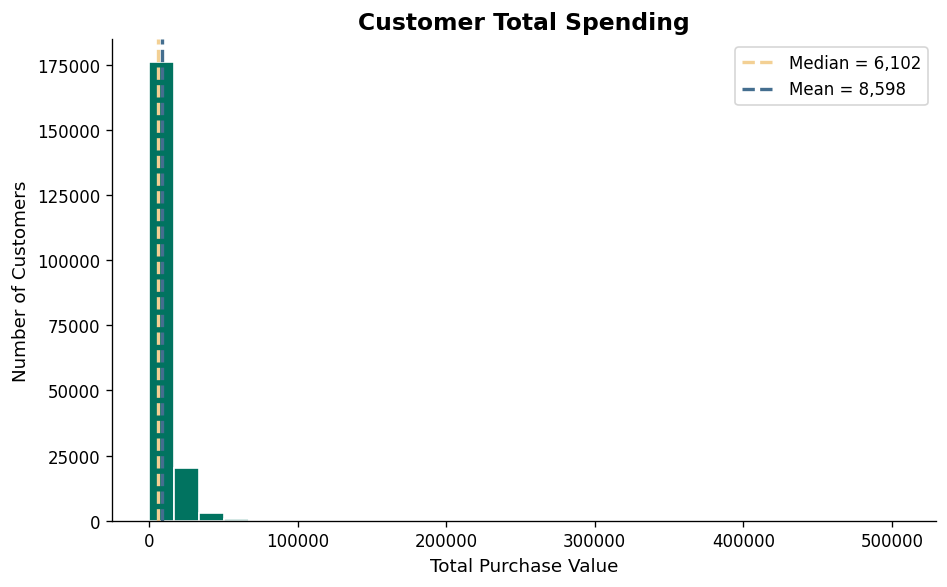

In [853]:
total_spend = customer_spending["total_spend"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    total_spend,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    total_spend.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {total_spend.median():,.0f}",
)

ax.axvline(
    total_spend.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {total_spend.mean():,.0f}",
)

ax.set_title("Customer Total Spending")
ax.set_xlabel("Total Purchase Value")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

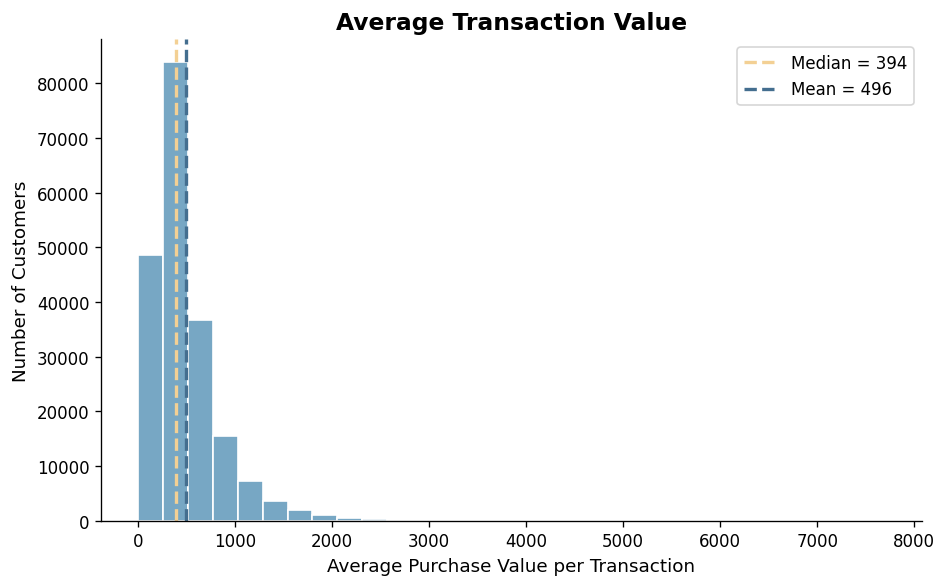

In [854]:
avg_transaction_value = (
    customer_spending["avg_transaction_value"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    avg_transaction_value,
    bins=30,
    color=COLORS["serene_sea"],
    edgecolor="white",
)

ax.axvline(
    avg_transaction_value.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {avg_transaction_value.median():,.0f}",
)

ax.axvline(
    avg_transaction_value.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {avg_transaction_value.mean():,.0f}",
)

ax.set_title("Average Transaction Value")
ax.set_xlabel("Average Purchase Value per Transaction")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

In [855]:
display(
    customer_spending[
        ["total_spend", "avg_transaction_value"]
    ]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)

,total_spend,avg_transaction_value
0.5000,"6,102.4400",393.9998
0.7500,"11,094.1850",608.7400
0.9000,"18,287.1280",926.0798
0.9500,"24,235.2540","1,193.4774"
0.9900,"41,865.7384","1,896.6470"


#### Spending Findings

The median customer spent about **6,102** during the available purchase
history, while the mean is higher at about **8,598**.

The mean being noticeably above the median tells us that a relatively small
group of high-spending customers pulls the average upward. This is also
visible in the upper end of the distribution: 75% of customers spent less
than about **11,094**, while a much smaller group spent far more.

The median customer also spent about **394 per transaction on average**.

This means spending gives us something frequency cannot show on its own.
Two customers may shop equally often, but one may spend much more each time.

At this point we can describe customer activity through three different
angles: how recently they shopped, how often they shopped, and how much money
they spent.

The next step looks at whether customers also differ in **what they buy**.

#### Product Behavior

Recency, frequency, and spending describe the level of customer activity.

Product behavior gives us another view: **how broad or narrow that activity is**.

We look at:

- The number of different products and product categories a customer buys;
- How strongly purchases are concentrated in one main category;
- The share of own-brand products in the customer's purchase history.

These measures help distinguish customers who shop broadly across the retailer
from customers whose purchases are focused on a narrower set of products.

In [856]:
customer_product_behavior = con.sql(
    """
    WITH product_lines AS (
        SELECT
            p.client_id,
            p.product_id,
            COALESCE(pr.level_2, 'UNKNOWN') AS level_2
        FROM purchases AS p

        INNER JOIN uplift_train AS u
            USING (client_id)

        INNER JOIN products AS pr
            USING (product_id)
    ),

    product_behavior AS (
        SELECT
            client_id,
            COUNT(DISTINCT product_id) AS unique_products,
            COUNT(DISTINCT level_2) AS unique_level_2_categories
        FROM product_lines
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        pb.unique_products,
        pb.unique_level_2_categories
    FROM uplift_train AS u

    LEFT JOIN product_behavior AS pb
        USING (client_id)
    """
).df()

display(customer_product_behavior.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_id,unique_products,unique_level_2_categories
0,000bc94494,124,19
1,000c049a1a,101,15
2,006008c3d6,44,8
3,007c1918a5,135,15
4,00a385016e,171,15


In [857]:
display(
    customer_product_behavior[
        [
            "unique_products",
            "unique_level_2_categories",
        ]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
unique_products,"200,039.0000",75.2873,56.3788,1.0000,35.0000,62.0000,101.0000,"1,364.0000"
unique_level_2_categories,"200,039.0000",12.3694,4.3468,1.0000,9.0000,12.0000,15.0000,37.0000


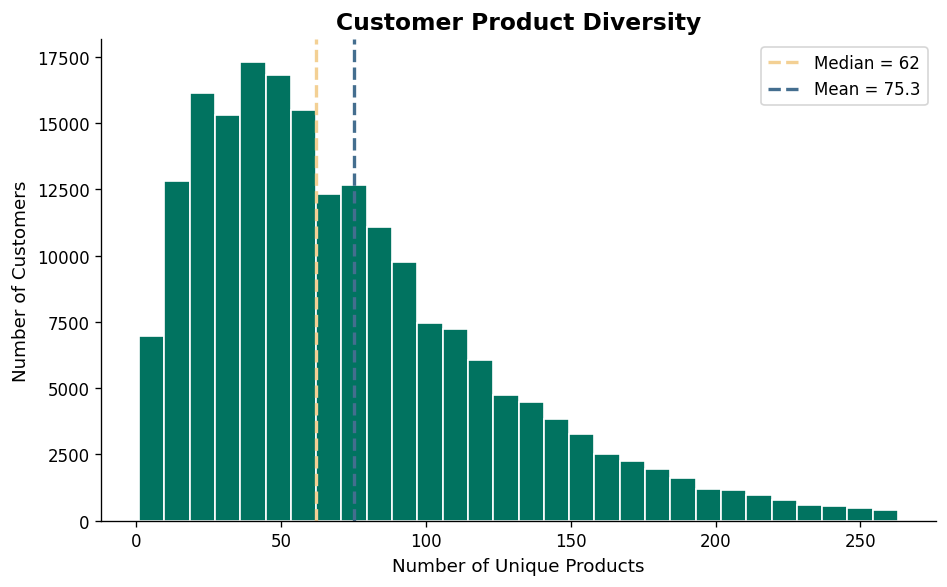

In [858]:
unique_products = (
    customer_product_behavior["unique_products"]
    .dropna()
)

product_p99 = unique_products.quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    unique_products[
        unique_products <= product_p99
    ],
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    unique_products.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {unique_products.median():.0f}",
)

ax.axvline(
    unique_products.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {unique_products.mean():.1f}",
)

ax.set_title("Customer Product Diversity")
ax.set_xlabel("Number of Unique Products")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

In [859]:
display(
    customer_product_behavior[
        [
            "unique_products",
            "unique_level_2_categories",
        ]
    ]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)

,unique_products,unique_level_2_categories
0.5000,62.0000,12.0000
0.7500,101.0000,15.0000
0.9000,149.0000,18.0000
0.9500,183.0000,20.0000
0.9900,263.0000,23.0000


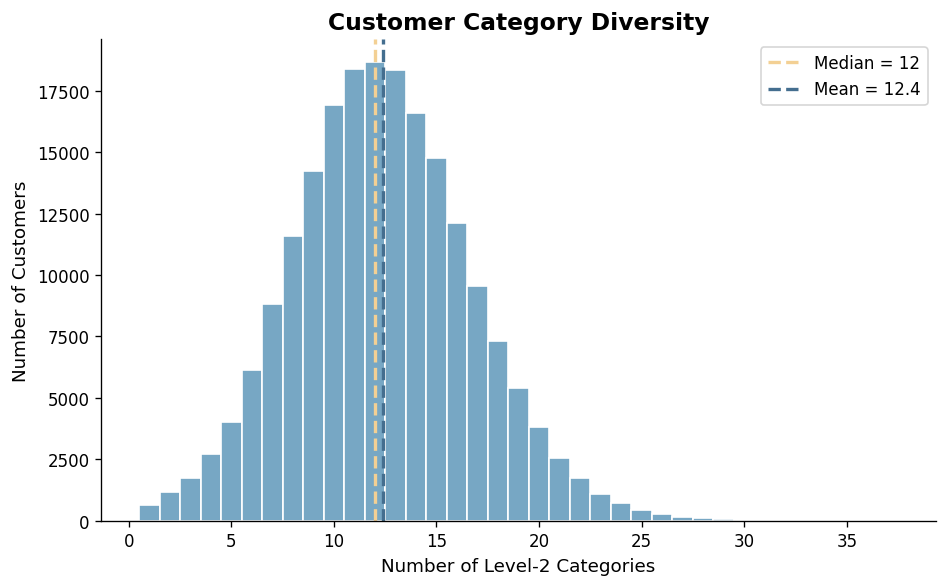

In [860]:
category_diversity = (
    customer_product_behavior[
        "unique_level_2_categories"
    ]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    category_diversity,
    bins=np.arange(
        category_diversity.min(),
        category_diversity.max() + 2,
    ) - 0.5,
    color=COLORS["serene_sea"],
    edgecolor="white",
)

ax.axvline(
    category_diversity.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {category_diversity.median():.0f}",
)

ax.axvline(
    category_diversity.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {category_diversity.mean():.1f}",
)

ax.set_title("Customer Category Diversity")
ax.set_xlabel("Number of Level-2 Categories")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

In [861]:
customer_category_concentration = con.sql(
    """
    WITH product_lines AS (
        SELECT
            p.client_id,
            COALESCE(pr.level_2, 'UNKNOWN') AS level_2
        FROM purchases AS p

        INNER JOIN uplift_train AS u
            USING (client_id)

        INNER JOIN products AS pr
            USING (product_id)
    ),

    category_counts AS (
        SELECT
            client_id,
            level_2,
            COUNT(*) AS purchase_lines
        FROM product_lines
        GROUP BY
            client_id,
            level_2
    ),

    concentration AS (
        SELECT
            client_id,
            MAX(purchase_lines) * 1.0
                / SUM(purchase_lines)
                AS dominant_category_share
        FROM category_counts
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        c.dominant_category_share
    FROM uplift_train AS u

    LEFT JOIN concentration AS c
        USING (client_id)
    """
).df()

display(customer_category_concentration.head())

,client_id,dominant_category_share
0,04915804ab,0.3333
1,1025dcdf07,0.2394
2,105952fc48,0.3333
3,10804229e8,0.2448
4,1883cf0990,0.2466


,count,mean,std,min,25%,50%,75%,max
dominant_category_share_pct,"200,039.0000",28.2066,10.5741,10.0000,21.2766,25.8065,32.2581,100.0000


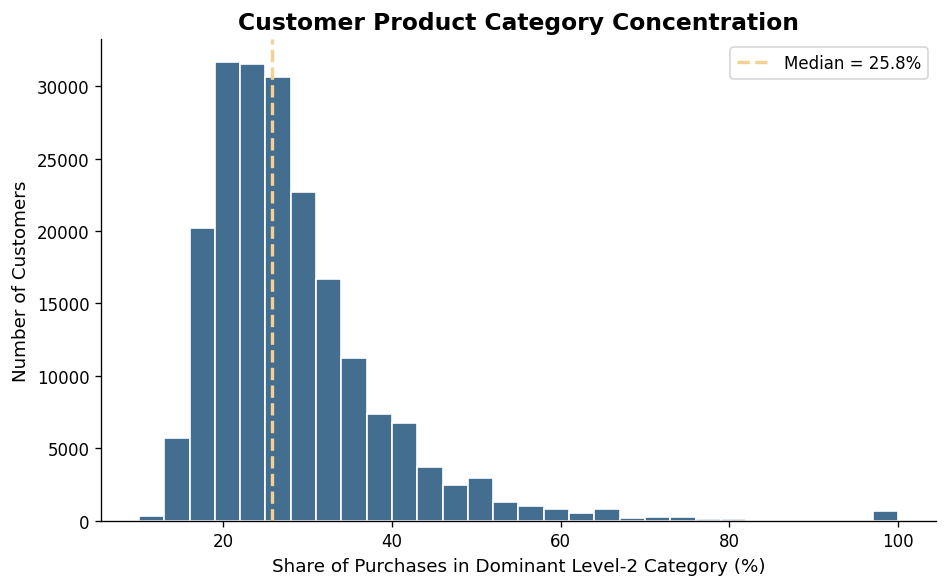

In [862]:
category_concentration = (
    customer_category_concentration[
        "dominant_category_share"
    ]
    .dropna()
    .mul(100)
)

display(
    category_concentration
    .describe()
    .to_frame("dominant_category_share_pct")
    .T
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    category_concentration,
    bins=30,
    color=COLORS["rainy_lake"],
    edgecolor="white",
)

ax.axvline(
    category_concentration.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {category_concentration.median():.1f}%",
)

ax.set_title("Customer Product Category Concentration")
ax.set_xlabel("Share of Purchases in Dominant Level-2 Category (%)")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

In [863]:
customer_product_preferences = con.sql(
    """
    WITH product_lines AS (
        SELECT
            p.client_id,
            pr.is_own_trademark,
            pr.is_alcohol
        FROM purchases AS p

        INNER JOIN uplift_train AS u
            USING (client_id)

        INNER JOIN products AS pr
            USING (product_id)
    ),

    preferences AS (
        SELECT
            client_id,

            AVG(is_own_trademark) AS own_brand_share,
            AVG(is_alcohol) AS alcohol_share

        FROM product_lines
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        p.own_brand_share,
        p.alcohol_share

    FROM uplift_train AS u

    LEFT JOIN preferences AS p
        USING (client_id)
    """
).df()

display(customer_product_preferences.head())

display(
    customer_product_preferences[
        ["own_brand_share", "alcohol_share"]
    ]
    .mul(100)
    .describe()
    .T
)

,client_id,own_brand_share,alcohol_share
0,0223e4711c,0.3333,0.0000
1,022727539c,0.1321,0.0000
2,02289edb42,0.1000,0.0000
3,022c1fd505,0.1935,0.0645
4,0239031631,0.0714,0.0000


,count,mean,std,min,25%,50%,75%,max
own_brand_share,"200,039.0000",15.3743,9.1275,0.0000,9.3939,14.2157,19.7674,100.0000
alcohol_share,"200,039.0000",1.8524,4.5680,0.0000,0.0000,0.0000,1.8182,100.0000


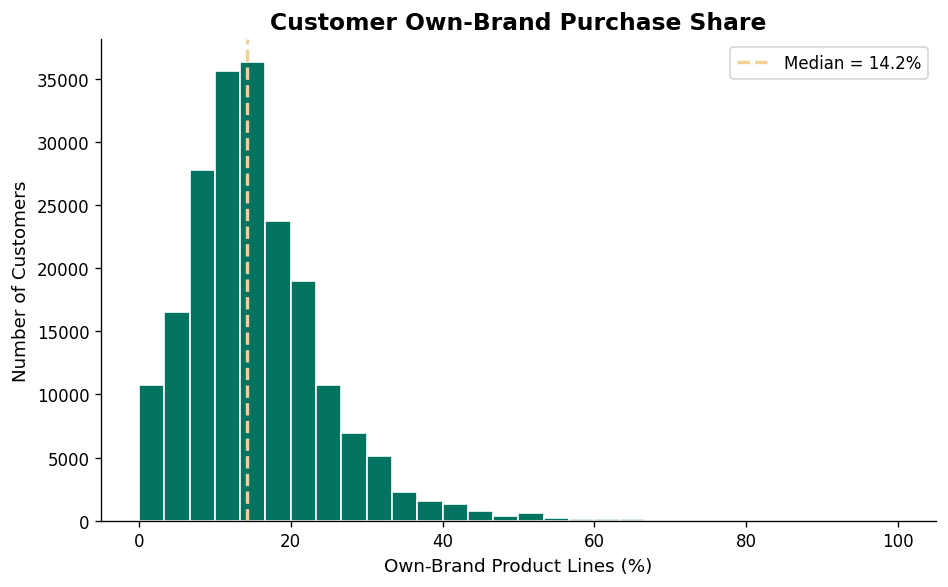

In [864]:
own_brand_share = (
    customer_product_preferences["own_brand_share"]
    .dropna()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    own_brand_share,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    own_brand_share.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {own_brand_share.median():.1f}%",
)

ax.set_title("Customer Own-Brand Purchase Share")
ax.set_xlabel("Own-Brand Product Lines (%)")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

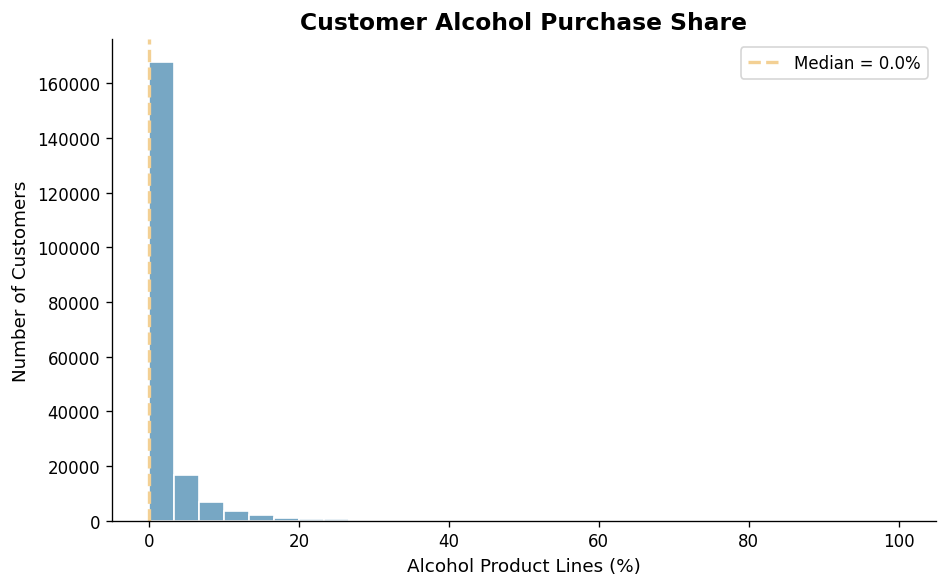

In [865]:
alcohol_share = (
    customer_product_preferences["alcohol_share"]
    .dropna()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    alcohol_share,
    bins=30,
    color=COLORS["serene_sea"],
    edgecolor="white",
)

ax.axvline(
    alcohol_share.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {alcohol_share.median():.1f}%",
)

ax.set_title("Customer Alcohol Purchase Share")
ax.set_xlabel("Alcohol Product Lines (%)")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()


#### Product Behavior Findings

Customers do not all shop across the product catalog in the same way.

The median customer purchased **62 different products** across **12 level-2
categories**. The middle half of customers used roughly **9 to 15 categories**.

So category breadth clearly varies across the population: some customers shop
inside a relatively small part of the catalog, while others buy across many
different categories.

The same story appears from the opposite direction. The dominant category
accounts for a median of about **25.8%** of a customer's purchase lines.
For a typical customer, no single category therefore explains most of their
shopping, although some customers are much more concentrated than others.

Own-brand share also varies. The median is about **14.2%**, with the middle
half of customers roughly between **9.4% and 19.8%**.


#### Store Behavior

Customers may also differ in where they shop.

- **Store diversity:** how many different stores a customer visited;
- **Store concentration:** how strongly the customer's transactions were concentrated in their most frequently visited store.

In [866]:
customer_store_behavior = con.sql(
    """
    WITH transactions AS (
        SELECT DISTINCT
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id
        FROM purchases AS p

        INNER JOIN uplift_train AS u
            USING (client_id)
    ),

    store_counts AS (
        SELECT
            client_id,
            store_id,
            COUNT(*) AS transactions
        FROM transactions
        GROUP BY
            client_id,
            store_id
    ),

    store_behavior AS (
        SELECT
            client_id,
            COUNT(*) AS unique_stores,
            MAX(transactions) * 1.0
                / SUM(transactions) AS dominant_store_share
        FROM store_counts
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        sb.unique_stores,
        sb.dominant_store_share
    FROM uplift_train AS u

    LEFT JOIN store_behavior AS sb
        USING (client_id)
    """
).df()

display(customer_store_behavior.head())

,client_id,unique_stores,dominant_store_share
0,178651039d,8,0.6207
1,551aec00bf,2,0.7500
2,7fd48bbf6e,1,1.0000
3,96e19983e8,9,0.7292
4,976671b99f,4,0.7143


In [867]:
store_behavior_summary = (
    customer_store_behavior[
        ["unique_stores", "dominant_store_share"]
    ]
    .copy()
)

store_behavior_summary["dominant_store_share"] *= 100

display(
    store_behavior_summary
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
unique_stores,"200,039.0000",2.9207,2.0052,1.0000,2.0000,2.0000,4.0000,95.0000
dominant_store_share,"200,039.0000",75.1867,22.2447,4.5455,57.1429,79.1667,98.9899,100.0000


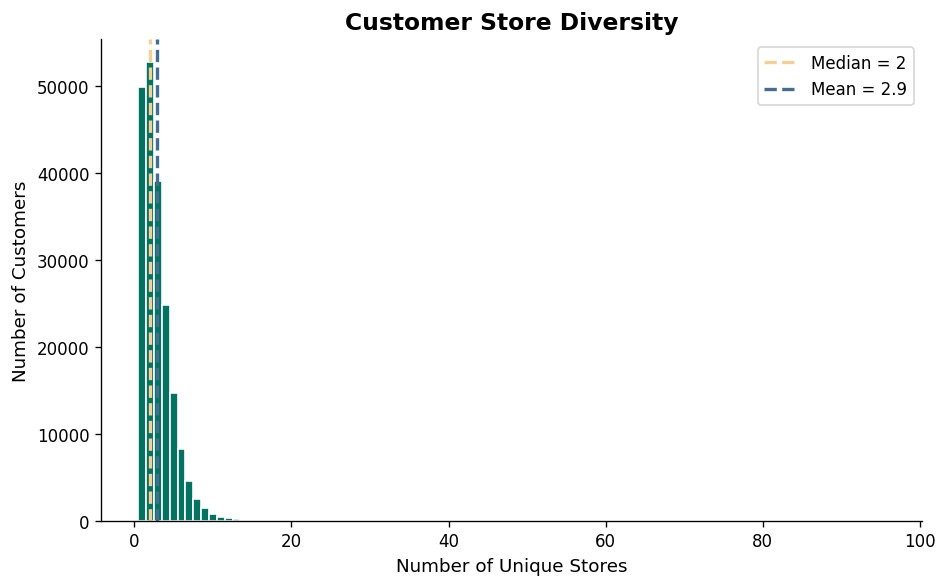

In [868]:
unique_stores = (
    customer_store_behavior["unique_stores"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(
    unique_stores.min(),
    unique_stores.max() + 2,
) - 0.5

ax.hist(
    unique_stores,
    bins=bins,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    unique_stores.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {unique_stores.median():.0f}",
)

ax.axvline(
    unique_stores.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {unique_stores.mean():.1f}",
)

ax.set_title("Customer Store Diversity")
ax.set_xlabel("Number of Unique Stores")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

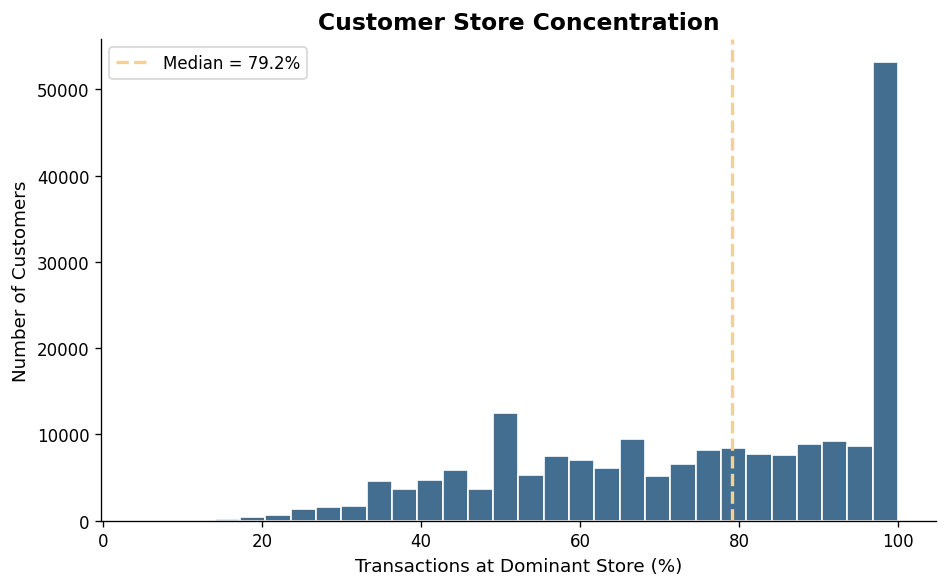

In [869]:
dominant_store_share = (
    customer_store_behavior["dominant_store_share"]
    .dropna()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    dominant_store_share,
    bins=30,
    color=COLORS["rainy_lake"],
    edgecolor="white",
)

ax.axvline(
    dominant_store_share.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {dominant_store_share.median():.1f}%",
)

ax.set_title("Customer Store Concentration")
ax.set_xlabel("Transactions at Dominant Store (%)")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

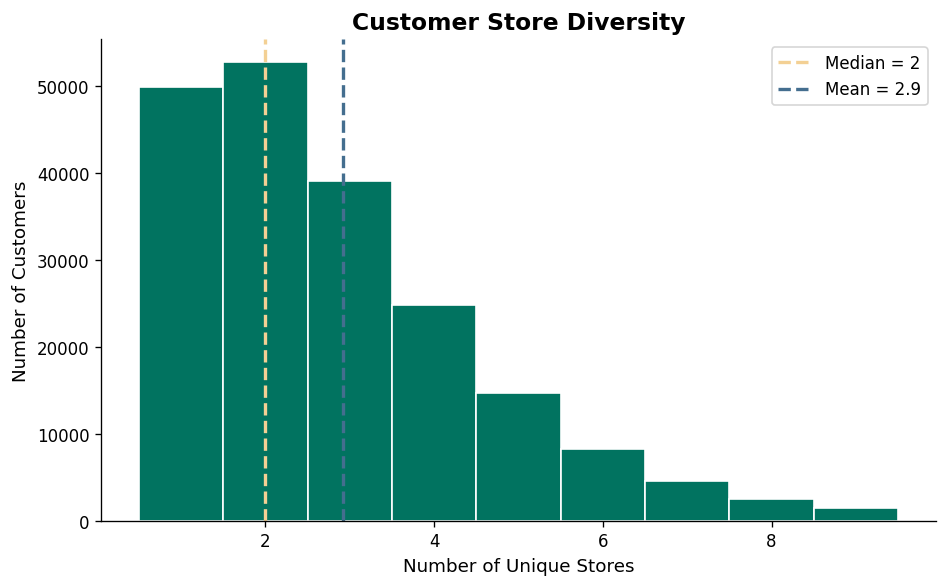

In [870]:
unique_stores = (
    customer_store_behavior["unique_stores"]
    .dropna()
)

store_p99 = unique_stores.quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    unique_stores[unique_stores <= store_p99],
    bins=np.arange(1, int(store_p99) + 2) - 0.5,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    unique_stores.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {unique_stores.median():.0f}",
)

ax.axvline(
    unique_stores.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {unique_stores.mean():.1f}",
)

ax.set_title("Customer Store Diversity")
ax.set_xlabel("Number of Unique Stores")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

#### Store Behavior Findings

Most customers shop at only a few stores.

The median customer used **2 stores**, and 75% used no more than **4** during
the available purchase history.

At the same time, customers usually have one store that dominates their
shopping. The median customer made about **79.2%** of all transactions at
their most frequently used store.

These two numbers fit together: customers may visit more than one store, but
most still do the majority of their shopping in one main location.

There is also enough variation for comparison. Some customers use only one
store, while others spread their purchases across several stores.

So store behavior gives us another useful distinction between customers:
**how broad their store usage is and how strongly they depend on one main store**.

### Customer and Purchase Behavior Summary

Customers are clearly different in how active they are, how much they spend,
how broadly they shop, and how they use stores.

These differences give us several useful ways to split the customer
population when we later look at campaign outcomes.

## 2. Outcome Overview

The outcome used in this experiment is `target`.

- `target = 1`: the customer made a purchase after the campaign period.
- `target = 0`: the customer did not make a purchase.

Before comparing Treatment and Control, first look at the outcome on its own.

This tells us how common a positive purchase outcome is in the full customer
population.

In [871]:
outcome_distribution = con.sql(
    """
    SELECT
        target,
        COUNT(*) AS customers,
        COUNT(*) * 100.0
            / SUM(COUNT(*)) OVER () AS percentage
    FROM uplift_train
    GROUP BY target
    ORDER BY target
    """
).df()

outcome_distribution["outcome"] = ["No Purchase","Purchase",]

display(outcome_distribution[["target", "outcome", "customers", "percentage"]])

positive_outcome_rate = outcome_distribution.loc[outcome_distribution["target"] == 1,"percentage",].iloc[0]

print(
    f"Positive outcome rate (target = 1): "
    f"{positive_outcome_rate:.2f}%"
)

,target,outcome,customers,percentage
0,0,No Purchase,76037,38.0111
1,1,Purchase,124002,61.9889


Positive outcome rate (target = 1): 61.99%


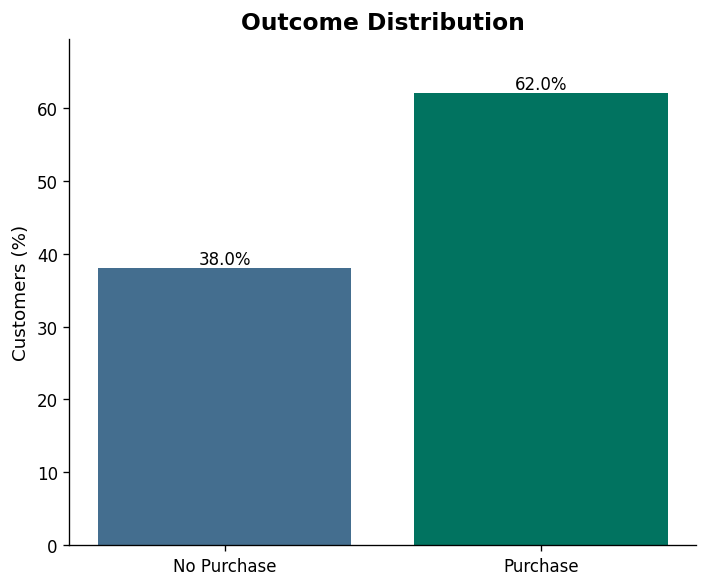

In [872]:
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    outcome_distribution["outcome"],
    outcome_distribution["percentage"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

ax.set_title("Outcome Distribution")
ax.set_ylabel("Customers (%)")

for bar, value in zip(
    bars,
    outcome_distribution["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_ylim(
    0,
    outcome_distribution["percentage"].max() * 1.12,
)

plt.tight_layout()
plt.show()

### Outcome Findings

There are **124,002 customers with a positive outcome**, accounting for about
**62.0%** of the experiment population. The remaining **76,037 customers**,
or about **38.0%**, did not make a purchase.

This means purchase is a common outcome in this dataset rather than a rare
event. Most customers eventually purchased, although a sizeable part of the
population still did not.

At this point, however, Treatment and Control are still mixed together. The
62% tells us how common the outcome is across all customers, but it does not
tell us whether receiving the campaign is connected to a higher purchase rate.


## 3. Overall Treatment-Control Difference

About **62%** of all customers have a positive purchase outcome, but that
number combines Treatment and Control.

Now separate the two groups:

- **Control:** customers who did not receive the promotional communication.
- **Treatment:** customers who received it.

This comparison shows whether the observed purchase rate is different between
customers who received the campaign and those who did not.

In [873]:
treatment_outcome = con.sql(
    """
    SELECT
        treatment_flg,
        COUNT(*) AS customers,
        AVG(target) * 100 AS purchase_rate
    FROM uplift_train
    GROUP BY treatment_flg
    ORDER BY treatment_flg
    """
).df()

treatment_outcome["group"] = ["Control","Treatment",]

display(treatment_outcome[["group", "customers", "purchase_rate"]])

control_rate = treatment_outcome.loc[treatment_outcome["treatment_flg"] == 0,"purchase_rate",].iloc[0]

treatment_rate = treatment_outcome.loc[treatment_outcome["treatment_flg"] == 1,"purchase_rate",].iloc[0]

observed_difference = treatment_rate - control_rate

print(f"Control purchase rate:   {control_rate:.2f}%")
print(f"Treatment purchase rate: {treatment_rate:.2f}%")
print(
    f"Observed difference:     "
    f"{observed_difference:+.2f} percentage points"
)

,group,customers,purchase_rate
0,Control,100058,60.3280
1,Treatment,99981,63.6511


Control purchase rate:   60.33%
Treatment purchase rate: 63.65%
Observed difference:     +3.32 percentage points


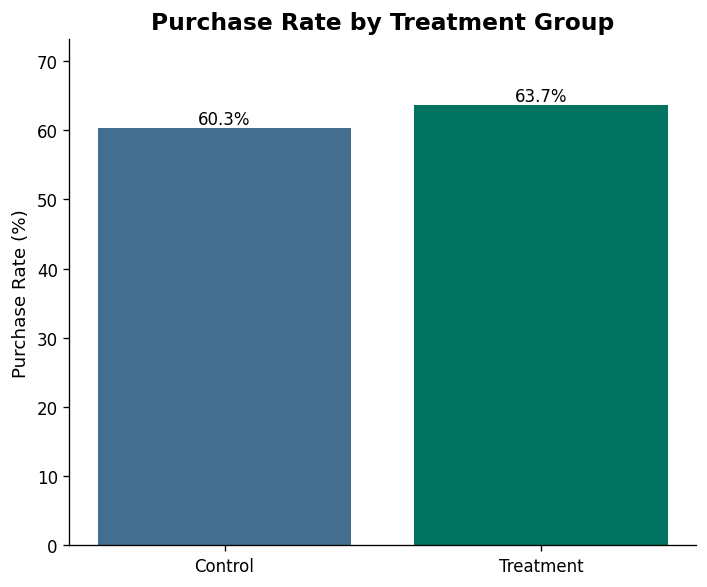

In [874]:
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    treatment_outcome["group"],
    treatment_outcome["purchase_rate"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

ax.set_title("Purchase Rate by Treatment Group")
ax.set_ylabel("Purchase Rate (%)")

for bar, value in zip(
    bars,
    treatment_outcome["purchase_rate"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_ylim(
    0,
    treatment_outcome["purchase_rate"].max() * 1.15,
)

plt.tight_layout()
plt.show()

### Overall Treatment-Control Findings

The Control group has a purchase rate of **60.33%**, while the Treatment
group reaches **63.65%**.

So the Treatment group is **3.32 percentage points higher** than Control.

These numbers matter together. A 60.33% purchase rate in Control means that
many customers were already purchasing even without the campaign. Treatment
raises the observed rate to 63.65%, so the difference between the two groups
is positive, but much smaller than the purchase rate itself.

In simple terms, for every 100 customers, Treatment has about **3.3 more
positive purchase outcomes** than Control.

This gives us the overall picture, but it is still only an average across very
different customers. A customer who already shops frequently may behave very
differently from someone who rarely shops.

## 4. Where Does the Treatment-Control Difference Change?

The overall Treatment-Control difference is positive, but customers had very different shopping behaviors before the campaign.

This section checks whether the difference becomes larger or smaller across those customer patterns.

The comparisons are exploratory. Their purpose is to find patterns worth checking further before feature engineering.





In [875]:
behavior_analysis = con.sql(
    """
    SELECT
        client_id,
        treatment_flg,
        target
    FROM uplift_train
    """
).df()

behavior_frames = [
    customer_recency,
    customer_frequency,
    customer_spending,
    customer_product_behavior,
    customer_category_concentration,
    customer_product_preferences,
    customer_store_behavior,
]

for frame in behavior_frames:
    behavior_analysis = behavior_analysis.merge(
        frame,
        on="client_id",
        how="left",
        validate="one_to_one",
    )

print(f"Customers: {len(behavior_analysis):,}")

display(behavior_analysis.head())

Customers: 200,039


,client_id,treatment_flg,target,last_purchase_date,recency_days,transaction_count,active_days,total_spend,avg_transaction_value,median_transaction_value,unique_products,unique_level_2_categories,dominant_category_share,own_brand_share,alcohol_share,unique_stores,dominant_store_share
0,000012768d,0,1,2019-03-14 15:01:47,4,4,4,"2,803.0000",700.7500,688.5000,46,8,0.3269,0.0769,0.0000,3,0.5000
1,000036f903,1,1,2019-03-17 10:29:37,1,32,32,"9,805.0000",306.4062,267.0000,96,12,0.2346,0.0864,0.0062,5,0.7812
2,00010925a5,1,1,2019-03-08 07:09:50,10,18,17,"5,883.0000",326.8333,301.0000,58,10,0.4103,0.1154,0.0128,2,0.6111
3,0001f552b0,1,1,2019-03-16 10:54:02,2,15,13,"6,155.1800",410.3453,335.3700,79,13,0.1977,0.1163,0.0000,4,0.6667
4,00020e7b18,1,1,2019-03-15 12:04:23,3,18,16,"25,819.6100","1,434.4228","1,222.6750",175,13,0.2831,0.1618,0.0000,4,0.6667


In [876]:
def plot_group_purchase_rates(
    summary,
    labels,
    title,
    xlabel,
):
    plot_df = summary.reset_index(drop=True)

    x = np.arange(len(plot_df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(9, 5))

    control_bars = ax.bar(
        x - width / 2,
        plot_df["control_rate"],
        width,
        label="Control",
        color=COLORS["rainy_lake"],
    )

    treatment_bars = ax.bar(
        x + width / 2,
        plot_df["treatment_rate"],
        width,
        label="Treatment",
        color=COLORS["pacific_green"],
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Purchase Rate (%)")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    max_rate = max(
        plot_df["control_rate"].max(),
        plot_df["treatment_rate"].max(),
    )

    ax.set_ylim(0, max_rate * 1.18)

    for bars in (control_bars, treatment_bars):
        for bar in bars:
            value = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    for i, row in plot_df.iterrows():
        top = max(
            row["control_rate"],
            row["treatment_rate"],
        )

        ax.text(
            x[i],
            top + max_rate * 0.07,
            f"Δ {row['observed_difference_pp']:+.2f} pp",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.legend()

    plt.tight_layout()
    plt.show()

### Grouping Strategy

For continuous measures such as recency, frequency, and spending, customers are divided into groups based on the values observed in the data.

For each group, we compare the **Control purchase rate**, the **Treatment purchase rate**, and the difference between them.

The two purchase rates show how likely customers in that group already are to buy. The gap between them shows where Treatment and Control are further apart.


### 4.1 Recency

Recency checks whether the campaign difference changes depending on how recently a customer last purchased.

In [877]:
recency_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "recency_days",
    ]
].dropna().copy()

recency_effect["recency_group"] = pd.qcut(
    recency_effect["recency_days"],
    q=4,
    duplicates="drop",
)

In [878]:
recency_group_profile = (
    recency_effect
    .groupby(
        "recency_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_days=("recency_days", "min"),
        max_days=("recency_days", "max"),
        median_days=("recency_days", "median"),
    )
)

recency_rates = (
    recency_effect
    .groupby(
        [
            "recency_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

recency_summary = (
    recency_group_profile
    .join(recency_rates)
)

recency_summary["observed_difference_pp"] = (
    recency_summary["treatment_rate"]
    - recency_summary["control_rate"]
)

display(
    recency_summary.reset_index(drop=True)
)

,customers,min_days,max_days,median_days,control_rate,treatment_rate,observed_difference_pp
0,57451,0,1,0.0000,80.1029,82.5807,2.4777
1,50462,2,4,3.0000,67.5431,70.1472,2.6041
2,44658,5,9,7.0000,50.3361,54.7436,4.4074
3,47468,10,22,14.0000,38.0908,42.2461,4.1553


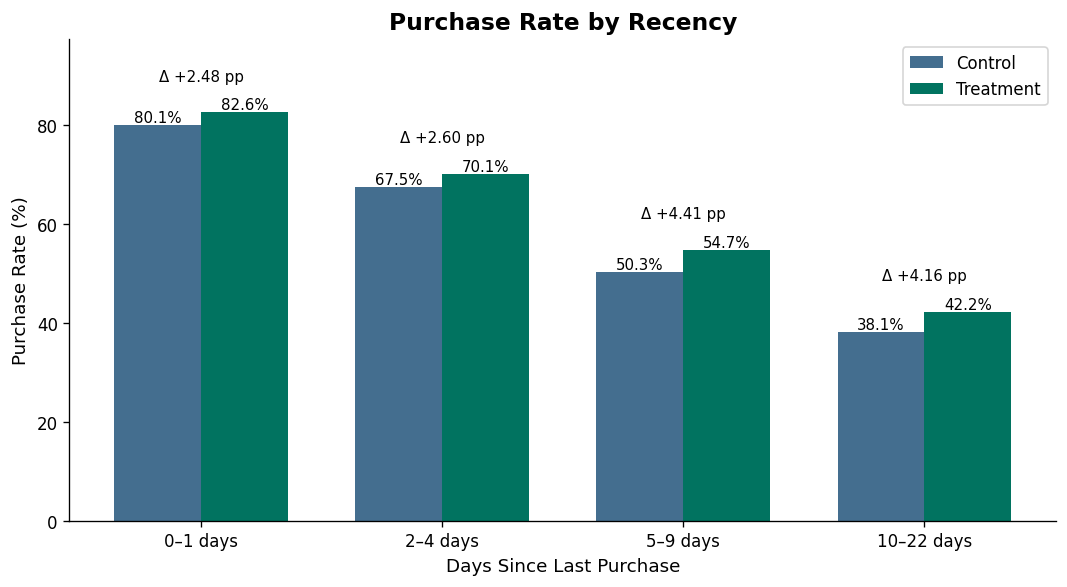

In [879]:
recency_labels = []

for row in recency_summary.itertuples():
    min_days = int(row.min_days)
    max_days = int(row.max_days)

    if min_days == max_days:
        label = f"{min_days} days"
    else:
        label = f"{min_days}–{max_days} days"

    recency_labels.append(label)

plot_group_purchase_rates(
    recency_summary,
    recency_labels,
    title="Purchase Rate by Recency",
    xlabel="Days Since Last Purchase",
)



#### Recency Findings

Customers who purchased within **0–1 days** already have purchase rates above **80%** in both Treatment and Control. Their Treatment-Control difference is only about **+2.5 percentage points**.

For customers whose last purchase was **5–22 days** ago, purchase rates are lower, while the difference grows to about **+4.2 to +4.4 points**.

So recent customers are already very likely to purchase even without treatment, while less-recent customers show a larger gap between Treatment and Control.

### 4.2 Frequency

Frequency checks the same idea using how often customers had already been shopping.



In [880]:
frequency_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "transaction_count",
    ]
].dropna().copy()

frequency_effect["frequency_group"] = pd.qcut(
    frequency_effect["transaction_count"],
    q=4,
    duplicates="drop",
)

In [881]:
frequency_group_profile = (
    frequency_effect
    .groupby(
        "frequency_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_transactions=("transaction_count", "min"),
        max_transactions=("transaction_count", "max"),
        median_transactions=("transaction_count", "median"),
    )
)

frequency_rates = (
    frequency_effect
    .groupby(
        [
            "frequency_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

frequency_summary = (
    frequency_group_profile
    .join(frequency_rates)
)

frequency_summary["observed_difference_pp"] = (
    frequency_summary["treatment_rate"]
    - frequency_summary["control_rate"]
)

display(
    frequency_summary.reset_index(drop=True)
)

,customers,min_transactions,max_transactions,median_transactions,control_rate,treatment_rate,observed_difference_pp
0,53315,1,8,5.0000,32.4286,36.8403,4.4117
1,48377,9,15,12.0000,53.3267,57.7857,4.4590
2,50584,16,27,21.0000,71.1453,73.5675,2.4223
3,47763,28,320,39.0000,87.3766,88.7656,1.3891


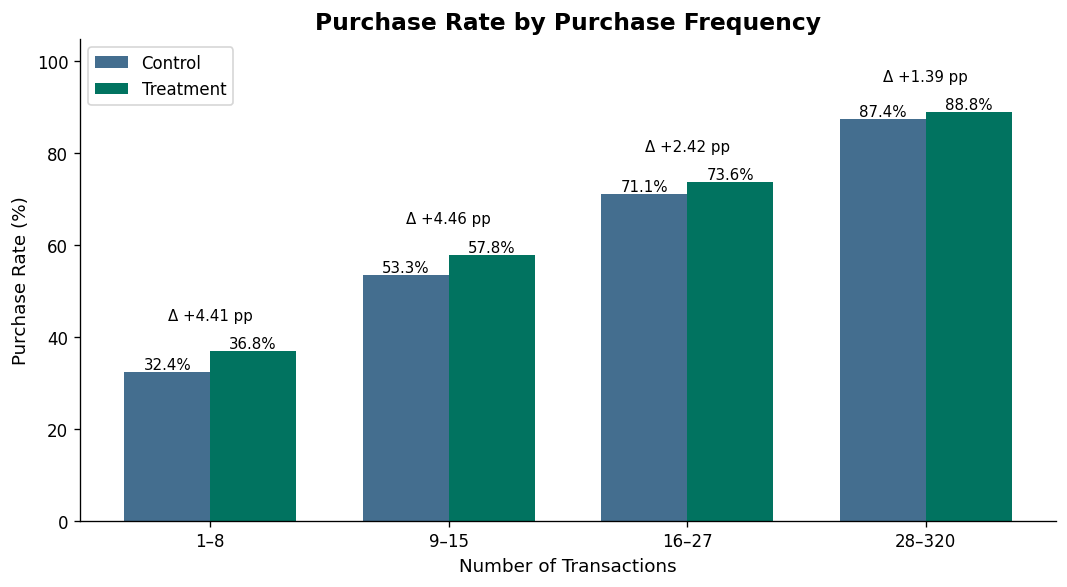

In [882]:
frequency_labels = []

for row in frequency_summary.itertuples():
    min_transactions = int(row.min_transactions)
    max_transactions = int(row.max_transactions)

    if min_transactions == max_transactions:
        label = f"{min_transactions}"
    else:
        label = f"{min_transactions}–{max_transactions}"

    frequency_labels.append(label)

plot_group_purchase_rates(
    frequency_summary,
    frequency_labels,
    title="Purchase Rate by Purchase Frequency",
    xlabel="Number of Transactions",
)

#### Frequency Findings

Customers with only **1–8 previous transactions** have much lower purchase rates, around **32% in Control and 37% in Treatment**, with a difference of about **+4.4 points**.

For customers with **28 or more transactions**, both purchase rates are already around **88%**, while the difference falls to only **+1.39 points**.

This gives the same pattern as recency: frequent shoppers are much more likely to purchase anyway, while the Treatment-Control gap is larger among less-frequent shoppers.



### 4.3 Spending

Spending checks whether the same pattern appears when customers are compared by how much they previously spent.



In [883]:
spending_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "total_spend",
    ]
].dropna().copy()

spending_effect["spending_group"] = pd.qcut(
    spending_effect["total_spend"],
    q=4,
    duplicates="drop",
)

In [884]:
spending_group_profile = (
    spending_effect
    .groupby(
        "spending_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_spend=("total_spend", "min"),
        max_spend=("total_spend", "max"),
        median_spend=("total_spend", "median"),
    )
)

spending_rates = (
    spending_effect
    .groupby(
        [
            "spending_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

spending_summary = (
    spending_group_profile
    .join(spending_rates)
)

spending_summary["observed_difference_pp"] = (
    spending_summary["treatment_rate"]
    - spending_summary["control_rate"]
)

display(
    spending_summary.reset_index(drop=True)
)

,customers,min_spend,max_spend,median_spend,control_rate,treatment_rate,observed_difference_pp
0,50010,1.0400,"3,147.6100","1,832.0000",37.2197,42.4529,5.2332
1,50010,"3,147.6200","6,102.4400","4,518.9600",55.5374,59.0778,3.5404
2,50009,"6,102.6700","11,094.0000","8,127.9100",68.4695,71.3916,2.9221
3,50010,"11,094.3700","504,490.3800","16,479.9100",80.3763,81.4159,1.0396


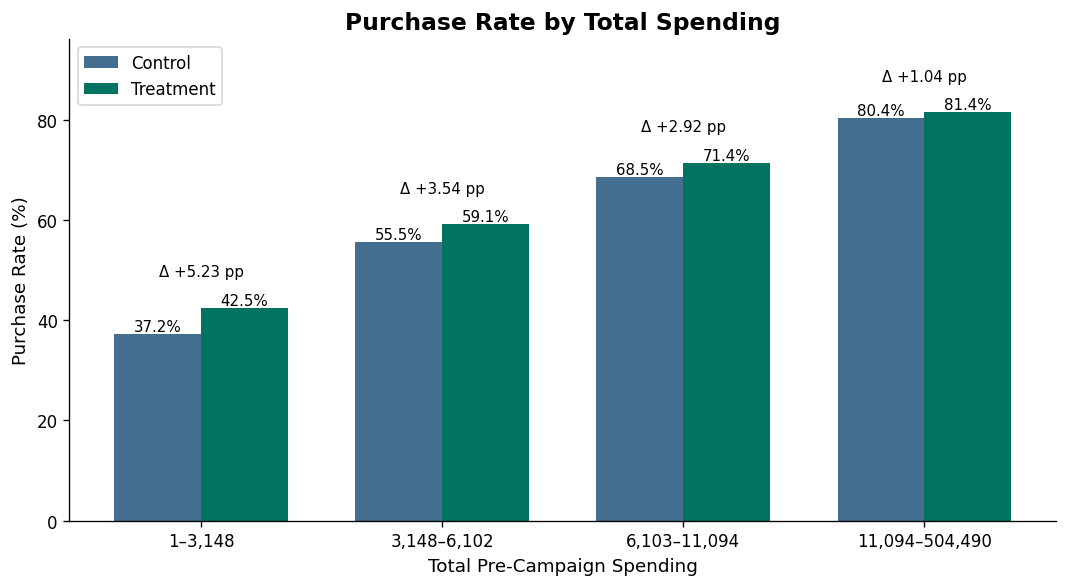

In [885]:
spending_labels = []

for row in spending_summary.itertuples():
    min_spend = row.min_spend
    max_spend = row.max_spend

    label = (
        f"{min_spend:,.0f}–{max_spend:,.0f}"
    )

    spending_labels.append(label)

plot_group_purchase_rates(
    spending_summary,
    spending_labels,
    title="Purchase Rate by Total Spending",
    xlabel="Total Pre-Campaign Spending",
)

#### Spending Findings

In the lowest-spending group, Control purchases at **37.22%** and Treatment at **42.45%**, giving the largest difference at **+5.23 points**.

In the highest-spending group, both rates are already around **80%**, while the difference falls to only **+1.04 points**.

Higher previous spending therefore goes together with a higher chance of purchasing anyway and a smaller Treatment-Control gap.



### Activity Pattern Summary

Recency, frequency, and spending point in the same direction:

**customers who were already more active are more likely to purchase anyway, while less-active customers show a larger Treatment-Control difference.**

The next checks look at whether the same pattern also appears in what customers buy.



### 4.4 Product Behavior

Product behavior looks beyond shopping activity and checks how broad or narrow a customer's purchases are.



#### Category Diversity

Category diversity measures how many different product categories a customer purchased from.



In [886]:
category_diversity_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "unique_level_2_categories",
    ]
].dropna().copy()

category_diversity_effect["category_diversity_group"] = pd.qcut(
    category_diversity_effect["unique_level_2_categories"],
    q=4,
    duplicates="drop",
)

In [887]:
category_diversity_profile = (
    category_diversity_effect
    .groupby(
        "category_diversity_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_categories=("unique_level_2_categories", "min"),
        max_categories=("unique_level_2_categories", "max"),
        median_categories=("unique_level_2_categories", "median"),
    )
)

category_diversity_rates = (
    category_diversity_effect
    .groupby(
        [
            "category_diversity_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

category_diversity_summary = (
    category_diversity_profile
    .join(category_diversity_rates)
)

category_diversity_summary["observed_difference_pp"] = (
    category_diversity_summary["treatment_rate"]
    - category_diversity_summary["control_rate"]
)

display(
    category_diversity_summary.reset_index(drop=True)
)

,customers,min_categories,max_categories,median_categories,control_rate,treatment_rate,observed_difference_pp
0,51058,1,9,8.0000,42.3271,47.8509,5.5238
1,53987,10,12,11.0000,58.1956,61.7064,3.5108
2,49688,13,15,14.0000,66.6599,69.2172,2.5573
3,45306,16,37,18.0000,76.3411,77.5554,1.2143


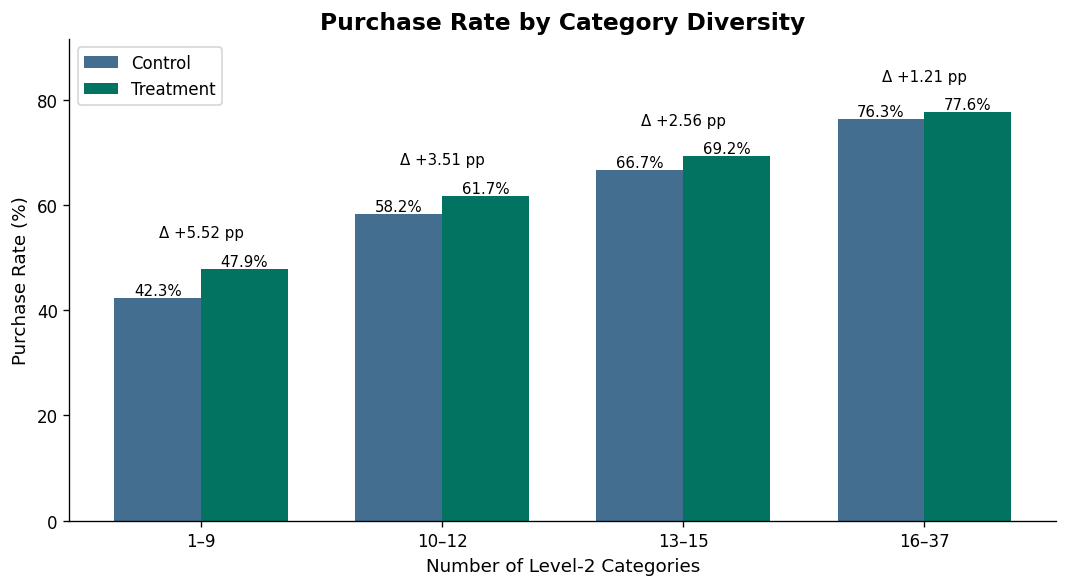

In [888]:
category_labels = []

for row in category_diversity_summary.itertuples():
    min_categories = int(row.min_categories)
    max_categories = int(row.max_categories)

    if min_categories == max_categories:
        label = f"{min_categories}"
    else:
        label = f"{min_categories}–{max_categories}"

    category_labels.append(label)

plot_group_purchase_rates(
    category_diversity_summary,
    category_labels,
    title="Purchase Rate by Category Diversity",
    xlabel="Number of Level-2 Categories",
)

#### Category Diversity Findings

Customers using only **1–9 categories** have purchase rates of **42.33% in Control and 47.85% in Treatment**, with a **+5.52-point** difference.

Among customers using **16–37 categories**, both rates rise to around **77%**, while the difference falls to only **+1.21 points**.

Customers who already shop across many categories are therefore more likely to purchase anyway, while customers with narrower category activity show a larger Treatment-Control gap.



#### Category Concentration

Category concentration looks at the same behavior from the opposite side: how much of a customer's shopping is concentrated in one main category.



In [889]:
category_concentration_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "dominant_category_share",
    ]
].dropna().copy()

category_concentration_effect["category_concentration_group"] = pd.qcut(
    category_concentration_effect["dominant_category_share"],
    q=4,
    duplicates="drop",
)

In [890]:
category_concentration_profile = (
    category_concentration_effect
    .groupby(
        "category_concentration_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_share=("dominant_category_share", "min"),
        max_share=("dominant_category_share", "max"),
        median_share=("dominant_category_share", "median"),
    )
)

category_concentration_rates = (
    category_concentration_effect
    .groupby(
        [
            "category_concentration_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

category_concentration_summary = (
    category_concentration_profile
    .join(category_concentration_rates)
)

category_concentration_summary["observed_difference_pp"] = (
    category_concentration_summary["treatment_rate"]
    - category_concentration_summary["control_rate"]
)

display(
    category_concentration_summary.reset_index(drop=True)
)

,customers,min_share,max_share,median_share,control_rate,treatment_rate,observed_difference_pp
0,50023,0.1000,0.2128,0.1886,65.3795,67.1583,1.7788
1,50164,0.2128,0.2581,0.2353,62.7405,65.8882,3.1476
2,50095,0.2581,0.3226,0.2857,60.6566,64.4206,3.7640
3,49757,0.3227,1.0000,0.3846,52.5258,57.0669,4.5411


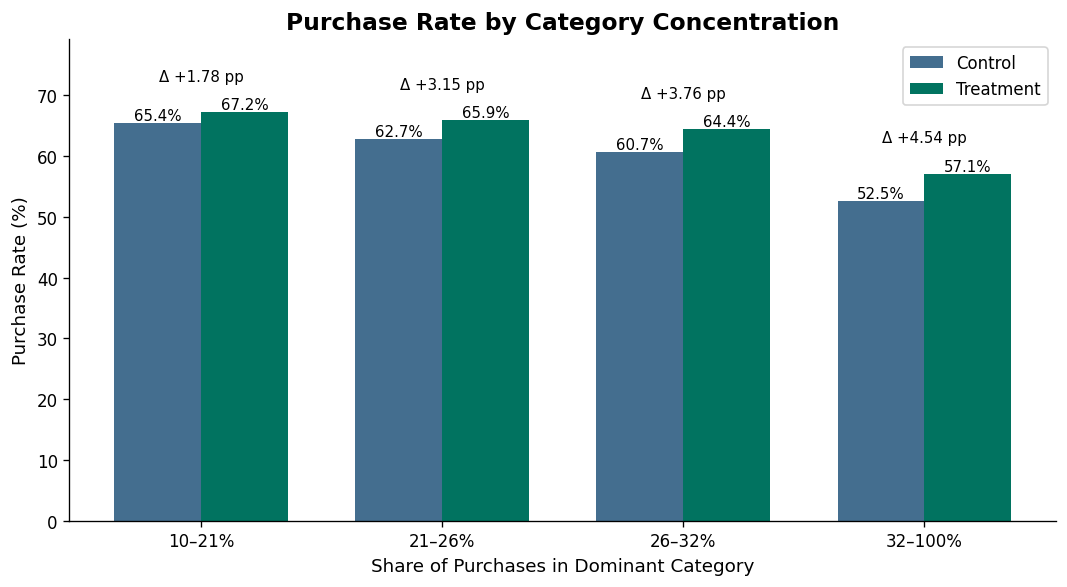

In [891]:
concentration_labels = []

for row in category_concentration_summary.itertuples():
    min_share = row.min_share * 100
    max_share = row.max_share * 100

    label = f"{min_share:.0f}–{max_share:.0f}%"
    concentration_labels.append(label)

plot_group_purchase_rates(
    category_concentration_summary,
    concentration_labels,
    title="Purchase Rate by Category Concentration",
    xlabel="Share of Purchases in Dominant Category",
)

#### Category Concentration Findings

When purchases are spread broadly across categories, the Treatment-Control difference is only **+1.78 points**.

As purchases become more concentrated in one category, the difference increases and reaches **+4.54 points** in the most concentrated group.

This supports the category-diversity result: **narrower product activity is linked to a larger observed Treatment-Control difference.**



#### Own-Brand Preference

Own-brand share checks whether product preference, rather than shopping breadth, shows a similar pattern.



In [892]:
own_brand_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "own_brand_share",
    ]
].dropna().copy()

own_brand_effect["own_brand_group"] = pd.qcut(
    own_brand_effect["own_brand_share"],
    q=4,
    duplicates="drop",
)

In [893]:
own_brand_profile = (
    own_brand_effect
    .groupby(
        "own_brand_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_share=("own_brand_share", "min"),
        max_share=("own_brand_share", "max"),
        median_share=("own_brand_share", "median"),
    )
)

own_brand_rates = (
    own_brand_effect
    .groupby(
        ["own_brand_group", "treatment_flg"],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

own_brand_summary = own_brand_profile.join(
    own_brand_rates
)

own_brand_summary["observed_difference_pp"] = (
    own_brand_summary["treatment_rate"]
    - own_brand_summary["control_rate"]
)

display(
    own_brand_summary.reset_index(drop=True)
)

,customers,min_share,max_share,median_share,control_rate,treatment_rate,observed_difference_pp
0,50012,0.0000,0.0939,0.0625,60.5213,64.6201,4.0988
1,50012,0.0940,0.1422,0.1186,63.7436,66.1453,2.4017
2,50020,0.1422,0.1977,0.1667,60.7473,63.8706,3.1233
3,49995,0.1977,1.0000,0.2500,56.3090,59.9729,3.6639


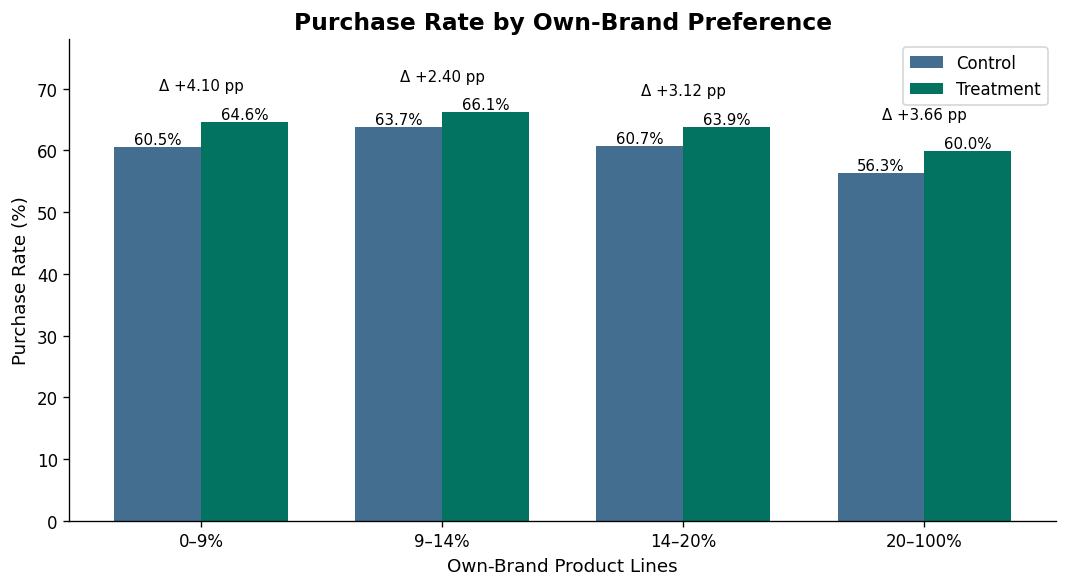

In [894]:
own_brand_labels = []

for row in own_brand_summary.itertuples():
    min_share = row.min_share * 100
    max_share = row.max_share * 100

    own_brand_labels.append(
        f"{min_share:.0f}–{max_share:.0f}%"
    )

plot_group_purchase_rates(
    own_brand_summary,
    own_brand_labels,
    title="Purchase Rate by Own-Brand Preference",
    xlabel="Own-Brand Product Lines",
)

#### Own-Brand Preference Findings

The Treatment-Control difference moves from **+4.10** to **+2.40**, then back to **+3.12** and **+3.66 points** across the four groups.

There is no clear direction as own-brand share increases.

Own-brand preference may still contain useful information, but this EDA does not show a strong pattern to prioritize on its own.



### 4.5 Store Behavior

The final check looks at whether where customers shop is also connected to the Treatment-Control difference.



In [895]:
store_concentration_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "dominant_store_share",
    ]
].dropna().copy()

store_concentration_effect["store_concentration_group"] = pd.qcut(
    store_concentration_effect["dominant_store_share"],
    q=4,
    duplicates="drop",
)

In [896]:
store_concentration_profile = (
    store_concentration_effect
    .groupby(
        "store_concentration_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_share=("dominant_store_share", "min"),
        max_share=("dominant_store_share", "max"),
        median_share=("dominant_store_share", "median"),
    )
)

store_concentration_rates = (
    store_concentration_effect
    .groupby(
        [
            "store_concentration_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

store_concentration_summary = (
    store_concentration_profile
    .join(store_concentration_rates)
)

store_concentration_summary["observed_difference_pp"] = (
    store_concentration_summary["treatment_rate"]
    - store_concentration_summary["control_rate"]
)

display(
    store_concentration_summary.reset_index(drop=True)
)

,customers,min_share,max_share,median_share,control_rate,treatment_rate,observed_difference_pp
0,51730,0.0455,0.5714,0.4667,57.7159,60.7271,3.0112
1,48381,0.5726,0.7917,0.6757,61.5312,65.0570,3.5258
2,49919,0.7922,0.9899,0.8889,70.1548,72.4257,2.2708
3,50009,0.9900,1.0000,1.0000,52.0624,56.5523,4.4899


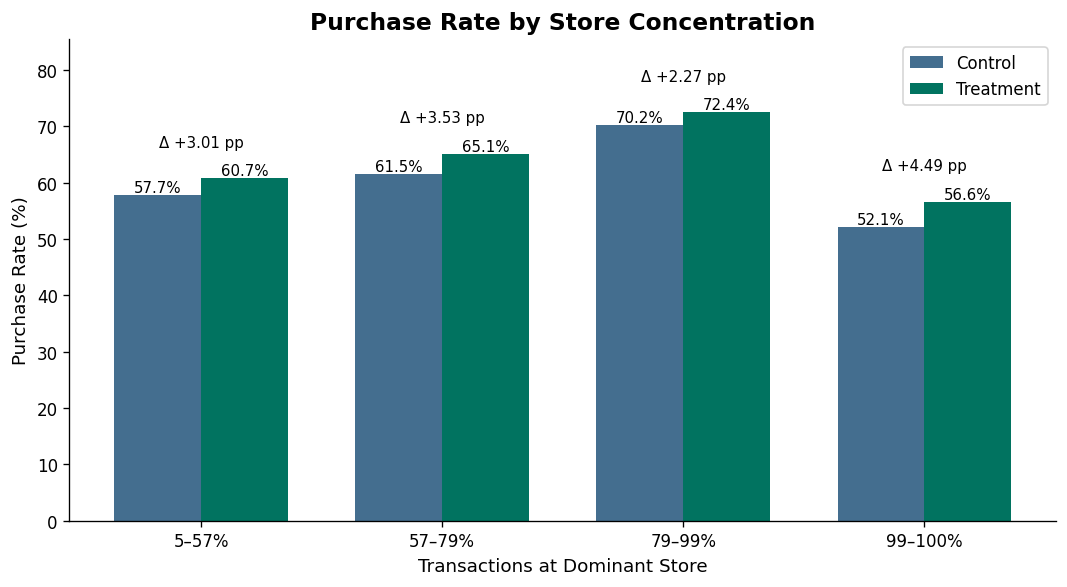

In [897]:
store_concentration_labels = []

for row in store_concentration_summary.itertuples():
    min_share = row.min_share * 100
    max_share = row.max_share * 100

    store_concentration_labels.append(
        f"{min_share:.0f}–{max_share:.0f}%"
    )


plot_group_purchase_rates(
    store_concentration_summary,
    store_concentration_labels,
    title="Purchase Rate by Store Concentration",
    xlabel="Transactions at Dominant Store",
)

#### Store Concentration Findings

The differences across the four groups are **+3.01, +3.53, +2.27, and +4.49 points**.

Because the values move up and down rather than in one clear direction, store concentration does not show a simple relationship with the Treatment-Control difference.



#### Number of Stores

Store diversity looks instead at how many different stores a customer uses.



In [898]:
store_diversity_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "unique_stores",
    ]
].dropna().copy()

store_diversity_effect["store_group"] = pd.cut(
    store_diversity_effect["unique_stores"],
    bins=[0, 1, 2, 4, np.inf],
    labels=[
        "1 store",
        "2 stores",
        "3–4 stores",
        "5+ stores",
    ],
)

In [899]:
store_diversity_summary = (
    store_diversity_effect
    .groupby(
        ["store_group", "treatment_flg"],
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        purchase_rate=("target", "mean"),
    )
    .reset_index()
)

store_diversity_summary["purchase_rate"] *= 100

store_diversity_rates = (
    store_diversity_summary
    .pivot(
        index="store_group",
        columns="treatment_flg",
        values="purchase_rate",
    )
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

store_diversity_counts = (
    store_diversity_effect
    .groupby(
        "store_group",
        observed=True,
    )["client_id"]
    .size()
    .rename("customers")
)

store_diversity_result = (
    store_diversity_counts
    .to_frame()
    .join(store_diversity_rates)
)

store_diversity_result["observed_difference_pp"] = (
    store_diversity_result["treatment_rate"]
    - store_diversity_result["control_rate"]
)

display(
    store_diversity_result.reset_index()
)

,store_group,customers,control_rate,treatment_rate,observed_difference_pp
0,1 store,49936,51.9992,56.4982,4.4990
1,2 stores,52773,57.5005,60.5650,3.0645
2,3–4 stores,63883,63.3171,66.3025,2.9853
3,5+ stores,33447,71.5516,74.1002,2.5487


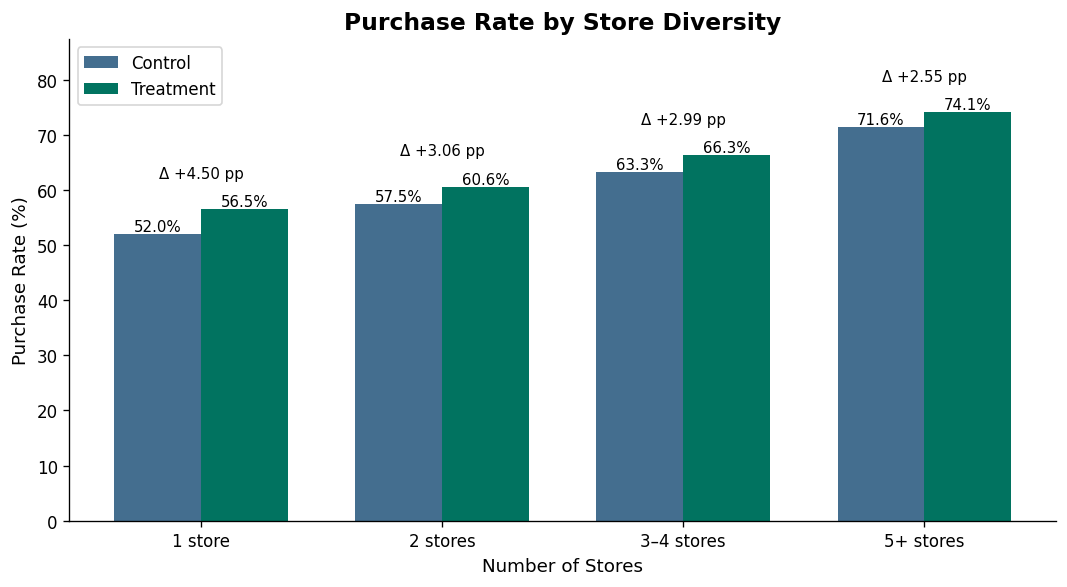

In [900]:
plot_group_purchase_rates(
    store_diversity_result,
    store_diversity_result.index.astype(str).tolist(),
    title="Purchase Rate by Store Diversity",
    xlabel="Number of Stores",
)

#### Store Diversity Findings

Customers using only **1 store** have purchase rates of **52.00% in Control and 56.50% in Treatment**, with a **+4.50-point** difference.

Customers using **5 or more stores** purchase much more often overall, at about **72–74%**, while the difference falls to **+2.55 points**.

This again matches the wider pattern: customers with broader existing activity are more likely to purchase anyway, while customers with narrower activity show a larger Treatment-Control gap.



### Treatment Effect Across Customer Behavior Summary

The EDA shows a consistent difference between customers who were already highly active before the campaign and those with lower prior activity.

Several patterns point in the same direction:

- **Recency:** customers who had not purchased as recently showed a larger treatment-control difference.
- **Frequency:** the difference decreased from about **4.4 percentage points** among lower-frequency customers to about **1.4 points** among the most frequent customers.
- **Spending:** lower-spending customers showed the largest difference (**+5.23 points**), while the highest-spending group showed only about **+1.04 point**.
- **Category diversity:** customers buying across fewer categories showed a larger difference than customers already shopping broadly.
- **Category concentration:** customers whose purchases were more concentrated in one category showed a larger treatment-control difference.
- **Store diversity:** customers shopping at fewer stores showed a larger difference than customers using many stores.

Together, these patterns suggest that customers who are already highly active and broadly engaged with the retailer are very likely to purchase even without treatment.

In contrast, customers with lower or narrower prior activity often have lower baseline purchase rates but a larger observed treatment-control difference.

Not every customer preference shows the same pattern. **Own-brand preference** and **store concentration** do not show a clear directional relationship with campaign response.

These findings provide the main patterns to carry forward into hypothesis checks before feature engineering.

## 5. Hypothesis Checks

The EDA found several patterns where the Treatment-Control difference changed
across customer groups.

The next step checks whether those differences are strong enough to support
the patterns seen in the EDA.

Because these hypotheses come from the same data used for the EDA, the results
are treated as supporting evidence rather than final confirmation.

### 5.1 Customer Activity

The EDA showed a similar pattern across recency, frequency, and spending:
customers who were already more active tended to have a smaller Treatment-Control difference.

The hypothesis is:

**H0:** The Treatment-Control difference stays the same across customer
activity groups.

**H1:** The Treatment-Control difference changes across customer activity
groups.


In [901]:
import statsmodels.formula.api as smf

In [902]:
def test_treatment_gap_by_group(df, group_col):
    test_df = df[
        [
            "target",
            "treatment_flg",
            group_col,
        ]
    ].dropna().copy()

    test_df["group"] = test_df[group_col].astype(str)

    model = smf.ols(
        "target ~ treatment_flg * C(group)",
        data=test_df,
    ).fit(cov_type="HC3")

    interaction_idx = [
        i
        for i, name in enumerate(model.params.index)
        if "treatment_flg" in name and ":" in name
    ]

    restriction = np.zeros(
        (
            len(interaction_idx),
            len(model.params),
        )
    )

    for row, idx in enumerate(interaction_idx):
        restriction[row, idx] = 1

    test = model.wald_test(
        restriction,
        scalar=True,
    )

    return float(test.pvalue)

In [903]:
activity_tests = [
    (
        "Recency",
        recency_effect,
        "recency_group",
    ),
    (
        "Frequency",
        frequency_effect,
        "frequency_group",
    ),
    (
        "Spending",
        spending_effect,
        "spending_group",
    ),
]

activity_test_results = []

for name, df, group_col in activity_tests:
    p_value = test_treatment_gap_by_group(
        df,
        group_col,
    )

    activity_test_results.append(
        {
            "measure": name,
            "p_value": p_value,
            "result": (
                "Supported"
                if p_value < 0.05
                else "Not supported"
            ),
        }
    )

activity_test_results = pd.DataFrame(
    activity_test_results
)

display(activity_test_results)

,measure,p_value,result
0,Recency,0.0004,Supported
1,Frequency,0.0000,Supported
2,Spending,0.0000,Supported


### 5.2 Product Breadth

The EDA showed that customers with narrower product activity tended to have
a larger Treatment-Control difference.

The hypothesis is:

**H0:** The Treatment-Control difference stays the same across different
levels of product breadth.

**H1:** The Treatment-Control difference changes across different levels of
product breadth.

This is checked using category diversity and category concentration.

In [904]:
product_tests = [
    (
        "Category Diversity",
        category_diversity_effect,
        "category_diversity_group",
    ),
    (
        "Category Concentration",
        category_concentration_effect,
        "category_concentration_group",
    ),
]

product_test_results = []

for name, df, group_col in product_tests:
    p_value = test_treatment_gap_by_group(
        df,
        group_col,
    )

    product_test_results.append(
        {
            "measure": name,
            "p_value": p_value,
            "result": (
                "Supported"
                if p_value < 0.05
                else "Not supported"
            ),
        }
    )

product_test_results = pd.DataFrame(
    product_test_results
)

display(product_test_results)

,measure,p_value,result
0,Category Diversity,0.0000,Supported
1,Category Concentration,0.0001,Supported


### 5.3 Store Breadth

The EDA showed that customers using fewer stores had a larger
Treatment-Control difference.

The hypothesis is:

**H0:** The Treatment-Control difference stays the same across store-breadth
groups.

**H1:** The Treatment-Control difference changes across store-breadth groups.

In [905]:
store_p_value = test_treatment_gap_by_group(
    store_diversity_effect,
    "store_group",
)

store_test_result = pd.DataFrame(
    [
        {
            "measure": "Store Diversity",
            "p_value": store_p_value,
            "result": (
                "Supported"
                if store_p_value < 0.05
                else "Not supported"
            ),
        }
    ]
)

display(store_test_result)

,measure,p_value,result
0,Store Diversity,0.0140,Supported


In [906]:
def treatment_gap_ci_by_group(df, group_col):
    rows = []

    for group_value, group_df in df.groupby(
        group_col,
        observed=True,
    ):
        group_df = group_df[
            ["target", "treatment_flg"]
        ].dropna()

        model = smf.ols(
            "target ~ treatment_flg",
            data=group_df,
        ).fit(cov_type="HC3")

        effect = model.params["treatment_flg"] * 100

        ci_lower, ci_upper = (
            model.conf_int()
            .loc["treatment_flg"]
            .mul(100)
        )

        rows.append(
            {
                "group": str(group_value),
                "difference_pp": effect,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
            }
        )

    return pd.DataFrame(rows)

In [907]:
ci_checks = [
    (
        "Recency",
        recency_effect,
        "recency_group",
    ),
    (
        "Frequency",
        frequency_effect,
        "frequency_group",
    ),
    (
        "Spending",
        spending_effect,
        "spending_group",
    ),
    (
        "Category Diversity",
        category_diversity_effect,
        "category_diversity_group",
    ),
    (
        "Category Concentration",
        category_concentration_effect,
        "category_concentration_group",
    ),
    (
        "Store Diversity",
        store_diversity_effect,
        "store_group",
    ),
]

ci_results = []

for measure, df, group_col in ci_checks:
    result = treatment_gap_ci_by_group(
        df,
        group_col,
    )

    result.insert(
        0,
        "measure",
        measure,
    )

    ci_results.append(result)

ci_results = pd.concat(
    ci_results,
    ignore_index=True,
)

display(ci_results)

,measure,group,difference_pp,ci_lower,ci_upper
0,Recency,"(-0.001, 1.0]",2.4777,1.8409,3.1145
1,Recency,"(1.0, 4.0]",2.6041,1.7963,3.4120
2,Recency,"(4.0, 9.0]",4.4074,3.4820,5.3328
3,Recency,"(9.0, 22.0]",4.1553,3.2740,5.0366
4,Frequency,"(0.999, 8.0]",4.4117,3.6048,5.2187
5,Frequency,"(8.0, 15.0]",4.4590,3.5742,5.3437
6,Frequency,"(15.0, 27.0]",2.4223,1.6431,3.2015
7,Frequency,"(27.0, 320.0]",1.3891,0.8077,1.9705
8,Spending,"(1.0390000000000001, 3147.615]",5.2332,4.3762,6.0903
9,Spending,"(3147.615, 6102.44]",3.5404,2.6739,4.4069


### Treatment-Control Difference Uncertainty

The confidence intervals support the same patterns seen in the EDA.

For every customer group examined, the **95% confidence interval remains above
zero**. This means the observed Treatment-Control purchase-rate difference is
positive across all of these groups.

However, the size of the difference changes noticeably.

For example:

- Recency increases from about **+2.5 points** among the most recent customers
  to about **+4.2–4.4 points** among less-recent customers.
- Frequency falls from about **+4.4 points** among lower-frequency customers
  to **+1.39 points** among the most frequent customers.
- Spending falls from **+5.23 points** in the lowest-spending group to only
  **+1.04 points** in the highest-spending group.
- Category diversity shows the same pattern, falling from **+5.52** to
  **+1.21 points** as customers shop across more categories.
- Category concentration moves in the opposite direction, increasing from
  **+1.78** to **+4.54 points** as purchases become more concentrated.
- Store diversity decreases from **+4.50 points** for customers using one
  store to **+2.55 points** for customers using five or more stores.

The interaction tests show that these differences across groups are
statistically supported, while the confidence intervals show that the
observed gaps themselves are positive and reasonably precise.

## Hypothesis Check Summary

All three patterns identified during the EDA are supported by the statistical
checks.

- **Customer activity:** supported by recency, frequency, and spending.
- **Product breadth:** supported by category diversity and category
  concentration.
- **Store breadth:** supported by store diversity.

The results support carrying these behaviors forward into feature engineering.

Own-brand preference and store concentration are not prioritized from the EDA
because they did not show a clear directional pattern.